In [1]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")

PyTorch: 2.7.1+cu118
CUDA   : True
GPU    : Quadro P3000


In [2]:
import os

volumes = [f"F:\\Full CNN\\msls_images_vol_{i}" for i in range(1, 7)]
metadata_base = r"F:\Full CNN\msls_metadata\train_val"

cities = os.listdir(metadata_base)
print(f"Total cities: {len(cities)}")
print(f"Cities: {cities}")

Total cities: 24
Cities: ['amman', 'amsterdam', 'austin', 'bangkok', 'berlin', 'boston', 'budapest', 'cph', 'goa', 'helsinki', 'london', 'manila', 'melbourne', 'moscow', 'nairobi', 'ottawa', 'paris', 'phoenix', 'saopaulo', 'sf', 'tokyo', 'toronto', 'trondheim', 'zurich']


In [3]:
import os

metadata_base = r"F:\Full CNN\msls_metadata\train_val"
volumes       = [f"F:\\Full CNN\\msls_images_vol_{i}" for i in range(1, 7)]

# المدن الفريدة من الميتاداتا
cities_raw = os.listdir(metadata_base)
cities     = list(set([c.lower() for c in cities_raw]))
print(f"Total cities: {len(cities)}")
print(f"Cities: {sorted(cities)}\n")

# نشوف الصور لكل مدينة
print(f"{'City':<15} {'DB Images':>12} {'Query Images':>14} {'Volume':>8}")
print("-" * 55)

for city in sorted(cities):
    db_count = 0
    q_count  = 0
    db_vol   = ""
    q_vol    = ""

    for vol in volumes:
        db_path = os.path.join(vol, 'train_val', city, 'database', 'images')
        q_path  = os.path.join(vol, 'train_val', city, 'query',    'images')

        if os.path.exists(db_path):
            count  = len([f for f in os.listdir(db_path) if f.endswith('.jpg')])
            db_count += count
            db_vol    = vol[-6:]

        if os.path.exists(q_path):
            count  = len([f for f in os.listdir(q_path) if f.endswith('.jpg')])
            q_count += count
            q_vol   = vol[-6:]

    print(f"{city:<15} {db_count:>12,} {q_count:>14,} {db_vol:>8}")

Total cities: 24
Cities: ['amman', 'amsterdam', 'austin', 'bangkok', 'berlin', 'boston', 'budapest', 'cph', 'goa', 'helsinki', 'london', 'manila', 'melbourne', 'moscow', 'nairobi', 'ottawa', 'paris', 'phoenix', 'saopaulo', 'sf', 'tokyo', 'toronto', 'trondheim', 'zurich']

City               DB Images   Query Images   Volume
-------------------------------------------------------
amman                    953            835   _vol_2
amsterdam             11,539          7,893   _vol_1
austin                28,462         14,222   _vol_3
bangkok               74,620         40,125   _vol_4
berlin                42,965         28,197   _vol_4
boston                14,024          6,724   _vol_2
budapest             153,321         45,800   _vol_1
cph                   12,601          6,595   _vol_4
goa                    5,722          5,362   _vol_2
helsinki              33,248         15,228   _vol_4
london                 3,291          2,692   _vol_5
manila                 6,064       

In [4]:
import os

metadata_base = r"F:\Full CNN\msls_metadata\train_val"
volumes       = [f"F:\\Full CNN\\msls_images_vol_{i}" for i in range(1, 7)]

# كل المدن في الميتاداتا
cities_raw = os.listdir(metadata_base)
print(f"Metadata folders ({len(cities_raw)}): {sorted(cities_raw)}\n")

# نشوف الصور لكل مدينة
print(f"{'City':<15} {'DB':>8} {'Query':>8} {'DB Vol':>8} {'Q Vol':>8}")
print("-" * 55)

for city in sorted(cities_raw):
    db_count = 0
    q_count  = 0
    db_vol   = "❌"
    q_vol    = "❌"

    for vol in volumes:
        db_path = os.path.join(vol, 'train_val', city, 'database', 'images')
        q_path  = os.path.join(vol, 'train_val', city, 'query',    'images')

        if os.path.exists(db_path):
            db_count = len([f for f in os.listdir(db_path) if f.endswith('.jpg')])
            db_vol   = vol[-6:]

        if os.path.exists(q_path):
            q_count = len([f for f in os.listdir(q_path) if f.endswith('.jpg')])
            q_vol   = vol[-6:]

    print(f"{city:<15} {db_count:>8,} {q_count:>8,} {db_vol:>8} {q_vol:>8}")

Metadata folders (24): ['amman', 'amsterdam', 'austin', 'bangkok', 'berlin', 'boston', 'budapest', 'cph', 'goa', 'helsinki', 'london', 'manila', 'melbourne', 'moscow', 'nairobi', 'ottawa', 'paris', 'phoenix', 'saopaulo', 'sf', 'tokyo', 'toronto', 'trondheim', 'zurich']

City                  DB    Query   DB Vol    Q Vol
-------------------------------------------------------
amman                953      835   _vol_2   _vol_2
amsterdam         11,539    7,893   _vol_1   _vol_2
austin            28,462   14,222   _vol_3   _vol_4
bangkok           74,620   40,125   _vol_4   _vol_5
berlin            42,965   28,197   _vol_4   _vol_4
boston            14,024    6,724   _vol_2   _vol_4
budapest         153,321   45,800   _vol_1   _vol_3
cph               12,601    6,595   _vol_4   _vol_4
goa                5,722    5,362   _vol_2   _vol_1
helsinki          33,248   15,228   _vol_4   _vol_6
london             3,291    2,692   _vol_5   _vol_6
manila             6,064    5,378   _vol_4   _vol

In [5]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from tqdm import tqdm
from PIL import Image

# ============================================
# Paths
# ============================================
BASE_DIR        = r"C:\Level 3 pytorch"
CHECKPOINTS_DIR = os.path.join(BASE_DIR, "checkpoints", "level1")
RESULTS_DIR     = os.path.join(BASE_DIR, "results", "level1")

os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,     exist_ok=True)

METADATA_BASE = r"F:\Full CNN\msls_metadata\train_val"
VOLUMES       = [f"F:\\Full CNN\\msls_images_vol_{i}" for i in range(1, 7)]

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 16
EPOCHS     = 10
LR         = 1e-4

# 24 مدينة
CITIES = sorted([
    'amman', 'amsterdam', 'austin', 'bangkok', 'berlin',
    'boston', 'budapest', 'cph', 'goa', 'helsinki',
    'london', 'manila', 'melbourne', 'moscow', 'nairobi',
    'ottawa', 'paris', 'phoenix', 'saopaulo', 'sf',
    'tokyo', 'toronto', 'trondheim', 'zurich'
])

CITY2IDX = {city: idx for idx, city in enumerate(CITIES)}
IDX2CITY = {idx: city for city, idx in CITY2IDX.items()}

print(f"Device    : {DEVICE}")
print(f"Num cities: {len(CITIES)}")
print(f"City2Idx  : {CITY2IDX}")

Device    : cuda
Num cities: 24
City2Idx  : {'amman': 0, 'amsterdam': 1, 'austin': 2, 'bangkok': 3, 'berlin': 4, 'boston': 5, 'budapest': 6, 'cph': 7, 'goa': 8, 'helsinki': 9, 'london': 10, 'manila': 11, 'melbourne': 12, 'moscow': 13, 'nairobi': 14, 'ottawa': 15, 'paris': 16, 'phoenix': 17, 'saopaulo': 18, 'sf': 19, 'tokyo': 20, 'toronto': 21, 'trondheim': 22, 'zurich': 23}


In [6]:
# ============================================
# Find Image Path for each city
# ============================================
def find_city_paths(city):
    db_path = None
    q_path  = None
    for vol in VOLUMES:
        p = os.path.join(vol, 'train_val', city, 'database', 'images')
        if os.path.exists(p):
            db_path = p
        p = os.path.join(vol, 'train_val', city, 'query', 'images')
        if os.path.exists(p):
            q_path = p
    return db_path, q_path

# ============================================
# Build Master DataFrame
# ============================================
def build_master_df():
    records = []
    for city in tqdm(CITIES, desc="Building master df"):
        meta_path = os.path.join(METADATA_BASE, city)
        db_img, q_img = find_city_paths(city)

        for role, img_dir in [('database', db_img), ('query', q_img)]:
            if img_dir is None:
                continue
            post_csv = os.path.join(meta_path, role, 'postprocessed.csv')
            seq_csv  = os.path.join(meta_path, role, 'seq_info.csv')
            if not os.path.exists(post_csv):
                continue

            post_df = pd.read_csv(post_csv)
            seq_df  = pd.read_csv(seq_csv)
            df      = post_df.merge(seq_df, on='key')
            df['full_path'] = df['key'].apply(
                lambda k: os.path.join(img_dir, k + '.jpg')
            )
            df['city']      = city
            df['label']     = CITY2IDX[city]
            df['role']      = role
            records.append(df)

    master = pd.concat(records, ignore_index=True)
    return master

master_df = build_master_df()

print(f"\nTotal images: {len(master_df):,}")
print(f"\nPer city (database):")
db = master_df[master_df['role'] == 'database']
for city in CITIES:
    n = len(db[db['city'] == city])
    print(f"  {city:<12}: {n:>8,}")

Building master df: 100%|██████████| 24/24 [00:14<00:00,  1.69it/s]



Total images: 1,464,298

Per city (database):
  amman       :      953
  amsterdam   :   11,539
  austin      :   28,462
  bangkok     :   74,620
  berlin      :   42,965
  boston      :   14,024
  budapest    :  153,321
  cph         :   12,601
  goa         :    5,722
  helsinki    :   33,248
  london      :    3,291
  manila      :    6,064
  melbourne   :  101,827
  moscow      :  171,878
  nairobi     :      437
  ottawa      :   69,756
  paris       :    9,503
  phoenix     :  106,221
  saopaulo    :   35,096
  sf          :    6,315
  tokyo       :   34,823
  toronto     :   12,789
  trondheim   :    5,015
  zurich      :    2,991


In [7]:
# ============================================
# Train / Val / Test Split
# ============================================
from sklearn.model_selection import GroupShuffleSplit

db_df   = master_df[master_df['role'] == 'database'].reset_index(drop=True)
q_df    = master_df[master_df['role'] == 'query'].reset_index(drop=True)

# Split database: 70% train, 15% val, 15% test
# بالـ sequence_key عشان نمنع leakage
gss_tv = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
idx_train, idx_temp = next(gss_tv.split(db_df, groups=db_df['sequence_key']))

train_df = db_df.iloc[idx_train].reset_index(drop=True)
temp_df  = db_df.iloc[idx_temp].reset_index(drop=True)

gss_vt = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
idx_val, idx_test = next(gss_vt.split(temp_df, groups=temp_df['sequence_key']))

val_df  = temp_df.iloc[idx_val].reset_index(drop=True)
test_df = temp_df.iloc[idx_test].reset_index(drop=True)

# تأكد من عدم وجود overlap
train_seqs = set(train_df['sequence_key'])
val_seqs   = set(val_df['sequence_key'])
test_seqs  = set(test_df['sequence_key'])

print(f"Train : {len(train_df):,} images")
print(f"Val   : {len(val_df):,} images")
print(f"Test  : {len(test_df):,} images")
print(f"\nTrain-Val overlap  : {len(train_seqs & val_seqs)}")
print(f"Train-Test overlap : {len(train_seqs & test_seqs)}")
print(f"Val-Test overlap   : {len(val_seqs & test_seqs)}")

Train : 664,422 images
Val   : 137,024 images
Test  : 142,015 images

Train-Val overlap  : 0
Train-Test overlap : 0
Val-Test overlap   : 0


In [8]:
# ============================================
# Transforms
# ============================================
transform_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomGrayscale(p=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std= [0.229, 0.224, 0.225])
])

transform_val = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std= [0.229, 0.224, 0.225])
])

# ============================================
# Dataset
# ============================================
class CityDataset(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img   = Image.open(row['full_path']).convert('RGB')
            img   = self.transform(img)
        except:
            img   = torch.zeros(3, 224, 224)
        label = int(row['label'])
        return img, label

# ============================================
# Model
# ============================================
class CityClassifier(nn.Module):
    def __init__(self, num_classes=24):
        super().__init__()
        backbone          = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_features       = backbone.classifier[1].in_features
        backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )
        self.model = backbone

    def forward(self, x):
        return self.model(x)

model_l1 = CityClassifier(num_classes=24).to(DEVICE)
total     = sum(p.numel() for p in model_l1.parameters())
print(f"Model parameters: {total:,}")
print("✅ Model ready")

Model parameters: 11,495,488
✅ Model ready


In [9]:
# ============================================
# تأكد من الـ Filtering والـ Normalizing
# ============================================
import matplotlib.pyplot as plt

# 1. تأكد من وجود الصور
print("=== Image Existence Check ===")
sample = train_df.sample(100, random_state=42)
exists = sample['full_path'].apply(os.path.exists).sum()
print(f"Existing images: {exists}/100")

# 2. تأكد من الـ Normalization
print("\n=== Normalization Check ===")
dataset_sample = CityDataset(train_df.sample(10, random_state=42), transform_train)
img, label = dataset_sample[0]
print(f"Image shape : {img.shape}")
print(f"Image min   : {img.min():.3f}")
print(f"Image max   : {img.max():.3f}")
print(f"Image mean  : {img.mean():.3f}")
print(f"Label       : {label} → {IDX2CITY[label]}")

# 3. تأكد من الـ Class Balance
print("\n=== Class Balance ===")
print(f"{'City':<15} {'Train':>10} {'Val':>10} {'Test':>10}")
print("-" * 50)
for city in CITIES:
    tr = len(train_df[train_df['city'] == city])
    vl = len(val_df[val_df['city']   == city])
    te = len(test_df[test_df['city'] == city])
    print(f"{city:<15} {tr:>10,} {vl:>10,} {te:>10,}")

# 4. تأكد من الـ Labels
print("\n=== Label Check ===")
print(f"Unique labels in train: {sorted(train_df['label'].unique())}")
print(f"Min label: {train_df['label'].min()} | Max label: {train_df['label'].max()}")

=== Image Existence Check ===
Existing images: 100/100

=== Normalization Check ===
Image shape : torch.Size([3, 224, 224])
Image min   : -2.118
Image max   : 2.640
Image mean  : -0.298
Label       : 6 → budapest

=== Class Balance ===
City                 Train        Val       Test
--------------------------------------------------
amman                  857         47         49
amsterdam            7,955      1,884      1,700
austin              20,090      3,379      4,993
bangkok             53,032     10,902     10,686
berlin              29,662      6,397      6,906
boston               8,159      2,709      3,156
budapest           109,170     23,410     20,741
cph                  9,318      1,733      1,550
goa                  3,661      1,203        858
helsinki            23,475      4,886      4,887
london               2,702        354        235
manila               4,263      1,121        680
melbourne           72,583     13,440     15,804
moscow             120,205 

In [10]:
# ============================================
# Fix 1: nairobi test = 0
# نحرك بعض صور val لـ test
# ============================================
nairobi_val  = val_df[val_df['city'] == 'nairobi']
nairobi_test = test_df[test_df['city'] == 'nairobi']

print(f"Nairobi val : {len(nairobi_val)}")
print(f"Nairobi test: {len(nairobi_test)}")

# ناخد نص صور nairobi من val ونحطها في test
nairobi_move = nairobi_val.sample(frac=0.5, random_state=42)
val_df       = val_df.drop(nairobi_move.index).reset_index(drop=True)
test_df      = pd.concat([test_df, nairobi_move], ignore_index=True)

print(f"\nAfter fix:")
print(f"Nairobi val : {len(val_df[val_df['city'] == 'nairobi'])}")
print(f"Nairobi test: {len(test_df[test_df['city'] == 'nairobi'])}")

# ============================================
# Fix 2: Weighted Sampler لمعالجة الـ Imbalance
# ============================================
city_counts  = train_df['city'].value_counts()
city_weights = 1.0 / city_counts
sample_weights = train_df['city'].map(city_weights).values

sampler = torch.utils.data.WeightedRandomSampler(
    weights     = torch.tensor(sample_weights, dtype=torch.float),
    num_samples = len(train_df),
    replacement = True
)

print("\n✅ Fixes applied")
print(f"Min weight: {min(sample_weights):.6f} (moscow)")
print(f"Max weight: {max(sample_weights):.6f} (nairobi)")

Nairobi val : 271
Nairobi test: 0

After fix:
Nairobi val : 135
Nairobi test: 136

✅ Fixes applied
Min weight: 0.000008 (moscow)
Max weight: 0.006024 (nairobi)


In [11]:
# ============================================
# Dataloaders
# ============================================
train_dataset = CityDataset(train_df, transform_train)
val_dataset   = CityDataset(val_df,   transform_val)
test_dataset  = CityDataset(test_df,  transform_val)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,
    num_workers = 0,
    pin_memory  = True
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True
)

print(f"Train batches: {len(train_loader):,}")
print(f"Val batches  : {len(val_loader):,}")

# ============================================
# Loss, Optimizer, Scheduler
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_l1.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

# ============================================
# Mixed Precision لتوفير الـ VRAM
# ============================================
scaler = torch.cuda.amp.GradScaler()

print("✅ Ready to train")

Train batches: 41,527
Val batches  : 8,556
✅ Ready to train


C:\Users\User\AppData\Local\Temp\ipykernel_9684\3361276736.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [12]:
scaler = torch.amp.GradScaler('cuda')
print("✅ Ready to train")

✅ Ready to train


In [13]:
# ============================================
# Dataloaders
# ============================================
train_dataset = CityDataset(train_df, transform_train)
val_dataset   = CityDataset(val_df,   transform_val)
test_dataset  = CityDataset(test_df,  transform_val)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,
    num_workers = 0,
    pin_memory  = True
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True
)

print(f"Train batches: {len(train_loader):,}")
print(f"Val batches  : {len(val_loader):,}")

# ============================================
# Loss, Optimizer, Scheduler
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_l1.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

# ============================================
# Mixed Precision لتوفير الـ VRAM
# ============================================
scaler = torch.cuda.amp.GradScaler()

print("✅ Ready to train")

Train batches: 41,527
Val batches  : 8,556
✅ Ready to train


C:\Users\User\AppData\Local\Temp\ipykernel_9684\3361276736.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [14]:
# ============================================
# Clear Cache
# ============================================
import gc
torch.cuda.empty_cache()
gc.collect()
print(f"GPU Memory Allocated: {torch.cuda.memory_allocated()/1024**2:.1f} MB")
print(f"GPU Memory Reserved : {torch.cuda.memory_reserved()/1024**2:.1f} MB")

# ============================================
# Sanity Check قبل التدريب
# ============================================
print("\n=== Sanity Check ===")

# 1. Model على الـ GPU
print(f"Model device: {next(model_l1.parameters()).device}")

# 2. تجربة batch واحدة
model_l1.train()
sample_imgs, sample_labels = next(iter(train_loader))
sample_imgs   = sample_imgs.to(DEVICE)
sample_labels = sample_labels.to(DEVICE)

with torch.amp.autocast('cuda'):
    outputs = model_l1(sample_imgs)
    loss    = criterion(outputs, sample_labels)

print(f"Input shape : {sample_imgs.shape}")
print(f"Output shape: {outputs.shape}")
print(f"Loss        : {loss.item():.4f}")
print(f"Predictions : {outputs.argmax(dim=1)[:5].tolist()}")
print(f"Labels      : {sample_labels[:5].tolist()}")

# 3. تأكد من الـ Accuracy calculation
preds   = outputs.argmax(dim=1)
correct = (preds == sample_labels).sum().item()
acc     = correct / len(sample_labels) * 100
print(f"Batch Acc   : {acc:.1f}%")

# 4. تأكد من الـ Checkpoint directory
print(f"\nCheckpoint dir: {CHECKPOINTS_DIR}")
print(f"Exists        : {os.path.exists(CHECKPOINTS_DIR)}")

print("\n✅ All checks passed, ready to train!")

GPU Memory Allocated: 44.3 MB
GPU Memory Reserved : 58.0 MB

=== Sanity Check ===
Model device: cuda:0
Input shape : torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 24])
Loss        : 3.1835
Predictions : [11, 4, 11, 11, 4]
Labels      : [13, 0, 10, 23, 9]
Batch Acc   : 0.0%

Checkpoint dir: C:\Level 3 pytorch\checkpoints\level1
Exists        : True

✅ All checks passed, ready to train!


In [15]:
torch.cuda.empty_cache()
import gc
gc.collect()
print("✅ Cache cleared")

✅ Cache cleared


In [16]:
import math

# ============================================
# ArcFace Layer
# ============================================
class ArcFaceLayer(nn.Module):
    def __init__(self, in_features, num_classes, s=64.0, m=0.5):
        super().__init__()
        self.in_features  = in_features
        self.num_classes  = num_classes
        self.s            = s
        self.m            = m
        self.weight       = nn.Parameter(
            torch.FloatTensor(num_classes, in_features)
        )
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th    = math.cos(math.pi - m)
        self.mm    = math.sin(math.pi - m) * m

    def forward(self, embeddings, labels):
        cosine = nn.functional.linear(
            nn.functional.normalize(embeddings),
            nn.functional.normalize(self.weight)
        )
        sine        = torch.sqrt(1.0 - torch.clamp(cosine**2, 0, 1))
        phi         = cosine * self.cos_m - sine * self.sin_m
        phi         = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot     = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        output      = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output      = output * self.s
        return output

# ============================================
# City Classifier with ArcFace
# ============================================
class CityClassifierArc(nn.Module):
    def __init__(self, emb_dim=512):
        super().__init__()
        backbone         = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_features      = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        self.backbone    = backbone
        self.embedding   = nn.Sequential(
            nn.Linear(in_features, emb_dim, bias=False),
            nn.BatchNorm1d(emb_dim)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.embedding(x)
        x = nn.functional.normalize(x, p=2, dim=1)
        return x

# ============================================
# Build Models
# ============================================
EMB_DIM    = 512
NUM_CLASS  = 24

model_l1   = CityClassifierArc(emb_dim=EMB_DIM).to(DEVICE)
arcface_l1 = ArcFaceLayer(
    in_features  = EMB_DIM,
    num_classes  = NUM_CLASS,
    s            = 64.0,
    m            = 0.5
).to(DEVICE)

total = sum(p.numel() for p in model_l1.parameters()) + \
        sum(p.numel() for p in arcface_l1.parameters())
print(f"Model parameters  : {sum(p.numel() for p in model_l1.parameters()):,}")
print(f"ArcFace parameters: {sum(p.numel() for p in arcface_l1.parameters()):,}")
print(f"Total parameters  : {total:,}")
print(" Model + ArcFace ready")

Model parameters  : 11,483,688
ArcFace parameters: 12,288
Total parameters  : 11,495,976
 Model + ArcFace ready


In [17]:
torch.cuda.empty_cache()
import gc
gc.collect()
print(f"GPU Memory Allocated: {torch.cuda.memory_allocated()/1024**2:.1f} MB")
print(f"GPU Memory Reserved : {torch.cuda.memory_reserved()/1024**2:.1f} MB")

GPU Memory Allocated: 1458.7 MB
GPU Memory Reserved : 1472.0 MB


In [20]:
BATCH_SIZE = 8

In [18]:
import gc

# ============================================
# Dataloaders
# ============================================
BATCH_SIZE = 16
EPOCHS     = 10
LR         = 1e-4

train_loader = DataLoader(
    CityDataset(train_df, transform_train),
    batch_size  = BATCH_SIZE,
    sampler     = sampler,
    num_workers = 0,
    pin_memory  = True
)
val_loader = DataLoader(
    CityDataset(val_df, transform_val),
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True
)

print(f"Train batches: {len(train_loader):,}")
print(f"Val batches  : {len(val_loader):,}")

# ============================================
# Optimizer, Scheduler, Scaler
# ============================================
optimizer = torch.optim.Adam([
    {'params': model_l1.parameters(),   'lr': LR},
    {'params': arcface_l1.parameters(), 'lr': LR},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

scaler    = torch.amp.GradScaler('cuda')
criterion = nn.CrossEntropyLoss()

# ============================================
# Sanity Check
# ============================================
model_l1.train()
arcface_l1.train()
sample_imgs, sample_labels = next(iter(train_loader))
sample_imgs   = sample_imgs.to(DEVICE)
sample_labels = sample_labels.to(DEVICE)

with torch.amp.autocast('cuda'):
    emb     = model_l1(sample_imgs)
    outputs = arcface_l1(emb, sample_labels)
    loss    = criterion(outputs, sample_labels)

print(f"\nSanity Check:")
print(f"  Embedding shape: {emb.shape}")
print(f"  Output shape   : {outputs.shape}")
print(f"  Loss           : {loss.item():.4f}")
print("  Ready to train")

Train batches: 41,527
Val batches  : 8,556

Sanity Check:
  Embedding shape: torch.Size([16, 512])
  Output shape   : torch.Size([16, 24])
  Loss           : 37.1202
  Ready to train


In [19]:
# تأكد إن الـ val loop هيشتغل صح
model_l1.eval()
arcface_l1.eval()
sample_imgs, sample_labels = next(iter(val_loader))
sample_imgs   = sample_imgs.to(DEVICE)
sample_labels = sample_labels.to(DEVICE)

with torch.no_grad():
    with torch.amp.autocast('cuda'):
        emb     = model_l1(sample_imgs)
        outputs = arcface_l1(emb, sample_labels)
        loss    = criterion(outputs, sample_labels)
        preds   = outputs.argmax(dim=1)
        acc     = (preds == sample_labels).float().mean() * 100

print(f"Val batch loss: {loss.item():.4f}")
print(f"Val batch acc : {acc.item():.1f}%")
print("✅ Val loop OK")

Val batch loss: 35.8351
Val batch acc : 0.0%
✅ Val loop OK


In [ ]:
"""
import gc
import os
import torch
import pandas as pd

# ============================================
# Load Checkpoint
# ============================================
ckpt = torch.load(os.path.join(CHECKPOINTS_DIR, 'level1_arc_best.pth'), map_location=DEVICE)
model_l1.load_state_dict(ckpt['model'])
arcface_l1.load_state_dict(ckpt['arcface'])
print(" level1_arc_best.pth loaded")

# ============================================
# Resume Setup
# ============================================
START_EPOCH  = 7      # خلص 7، هنبدأ من 8
best_val_acc = 86.88  # آخر best محفوظ
history      = []

print("="*55)
print(f"Resuming Level 1 Training from Epoch {START_EPOCH + 1}")
print(f"Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}")
print(f"Train batches: {len(train_loader):,}")
print(f"Val batches  : {len(val_loader):,}")
print(f"Best Val so far: {best_val_acc:.2f}%")
print("="*55)

# Scheduler للـ epoch الصح
for _ in range(START_EPOCH):
    scheduler.step()

print(f"LR now: {scheduler.get_last_lr()[0]:.2e}")

# ============================================
# Training Loop
# ============================================
for epoch in range(START_EPOCH, EPOCHS):
    # Train
    model_l1.train()
    arcface_l1.train()
    train_loss    = 0.0
    train_correct = 0
    train_total   = 0

    for step, (imgs, labels) in enumerate(train_loader):
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            emb     = model_l1(imgs)
            outputs = arcface_l1(emb, labels)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            list(model_l1.parameters()) +
            list(arcface_l1.parameters()), 1.0
        )
        scaler.step(optimizer)
        scaler.update()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

        if step % 500 == 0:
            acc = train_correct / train_total * 100
            print(f"  Epoch {epoch+1:>2} | Step {step:>5} | "
                  f"Loss: {loss.item():.4f} | Acc: {acc:.1f}%")

    # Validation
    model_l1.eval()
    arcface_l1.eval()
    val_loss    = 0.0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.amp.autocast('cuda'):
                emb     = model_l1(imgs)
                outputs = arcface_l1(emb, labels)
                loss    = criterion(outputs, labels)
            val_loss    += loss.item()
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    avg_train_loss = train_loss    / len(train_loader)
    avg_val_loss   = val_loss      / len(val_loader)
    train_acc      = train_correct / train_total * 100
    val_acc        = val_correct   / val_total   * 100

    scheduler.step()
    lr_now = scheduler.get_last_lr()[0]

    history.append({
        'epoch'     : epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss'  : avg_val_loss,
        'train_acc' : train_acc,
        'val_acc'   : val_acc,
        'lr'        : lr_now
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model'  : model_l1.state_dict(),
            'arcface': arcface_l1.state_dict(),
        }, os.path.join(CHECKPOINTS_DIR, 'level1_arc_best.pth'))
        saved = " Saved"
    else:
        saved = " No improvement"

    print(f"\nEpoch {epoch+1:>2}/{EPOCHS} | LR: {lr_now:.2e}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss  : {avg_val_loss:.4f} | Val Acc  : {val_acc:.2f}%")
    print(f"  Best Val  : {best_val_acc:.2f}%  {saved}")
    print("-"*55)

    torch.cuda.empty_cache()
    gc.collect()

pd.DataFrame(history).to_csv(
    os.path.join(RESULTS_DIR, 'level1_arc_history_resumed.csv'), index=False
)
print("\n Resumed Training Complete!")
print(f"Best Val Accuracy: {best_val_acc:.2f}%")
"""

 level1_arc_best.pth loaded
Resuming Level 1 Training from Epoch 8
Epochs: 10 | Batch: 16 | LR: 0.0001
Train batches: 41,527
Val batches  : 8,556
Best Val so far: 86.88%
LR now: 2.14e-05


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


  Epoch  8 | Step     0 | Loss: 0.0000 | Acc: 100.0%
  Epoch  8 | Step   500 | Loss: 2.0506 | Acc: 94.1%
  Epoch  8 | Step  1000 | Loss: 0.3399 | Acc: 93.9%
  Epoch  8 | Step  1500 | Loss: 0.7516 | Acc: 93.8%
  Epoch  8 | Step  2000 | Loss: 0.3055 | Acc: 93.7%
  Epoch  8 | Step  2500 | Loss: 3.0884 | Acc: 93.7%
  Epoch  8 | Step  3000 | Loss: 0.7749 | Acc: 93.6%
  Epoch  8 | Step  3500 | Loss: 0.5102 | Acc: 93.6%
  Epoch  8 | Step  4000 | Loss: 0.0000 | Acc: 93.6%
  Epoch  8 | Step  4500 | Loss: 3.3829 | Acc: 93.6%
  Epoch  8 | Step  5000 | Loss: 1.8036 | Acc: 93.6%
  Epoch  8 | Step  5500 | Loss: 2.5685 | Acc: 93.5%
  Epoch  8 | Step  6000 | Loss: 1.4773 | Acc: 93.5%
  Epoch  8 | Step  6500 | Loss: 4.5235 | Acc: 93.5%
  Epoch  8 | Step  7000 | Loss: 1.9429 | Acc: 93.5%
  Epoch  8 | Step  7500 | Loss: 1.2418 | Acc: 93.5%
  Epoch  8 | Step  8000 | Loss: 1.7154 | Acc: 93.5%
  Epoch  8 | Step  8500 | Loss: 0.0000 | Acc: 93.5%
  Epoch  8 | Step  9000 | Loss: 0.0142 | Acc: 93.5%
  Epoch  8 

# evaluation , testing , and confusion matrix

In [25]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


Imports + Load Checkpoint

In [20]:
import gc
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

ckpt = torch.load(os.path.join(CHECKPOINTS_DIR, 'level1_arc_best.pth'), map_location=DEVICE)
model_l1.load_state_dict(ckpt['model'])
arcface_l1.load_state_dict(ckpt['arcface'])
print(" level1_arc_best.pth loaded")

 level1_arc_best.pth loaded


 Evaluate Function + Validation

In [27]:
CITY_NAMES = [k for k, v in sorted(CITY2IDX.items(), key=lambda x: x[1])]

def evaluate(loader, split_name):
    model_l1.eval()
    arcface_l1.eval()
    all_preds  = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.amp.autocast('cuda'):
                emb     = model_l1(imgs)
                outputs = arcface_l1(emb, labels)
                loss    = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc      = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
    avg_loss = total_loss / len(loader)


    print(f"{split_name} Results")

    print(f"Loss    : {avg_loss:.4f}")
    print(f"Accuracy: {acc:.2f}%")

    return np.array(all_preds), np.array(all_labels), acc

val_preds, val_labels, val_acc = evaluate(val_loader, "Validation")

Validation Results
Loss    : 4.8319
Accuracy: 88.18%


In [21]:
import gc
import os
import torch
import pandas as pd

# ============================================
# Load Checkpoint
# ============================================
ckpt = torch.load(os.path.join(CHECKPOINTS_DIR, 'level1_arc_best.pth'), map_location=DEVICE)
model_l1.load_state_dict(ckpt['model'])
arcface_l1.load_state_dict(ckpt['arcface'])
print("✅ level1_arc_best.pth loaded")

# ============================================
# Resume Setup
# ============================================
EPOCHS       = 15     # ← من 10 لـ 15
START_EPOCH  = 10     # ← خلص 10، هنبدأ من 11
best_val_acc = 88.18  # ← آخر best محفوظ
history      = []

print("="*55)
print(f"Resuming Level 1 Training from Epoch {START_EPOCH + 1}")
print(f"Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}")
print(f"Train batches: {len(train_loader):,}")
print(f"Val batches  : {len(val_loader):,}")
print(f"Best Val so far: {best_val_acc:.2f}%")
print("="*55)

# Scheduler للـ epoch الصح
optimizer = torch.optim.Adam([
    {'params': model_l1.parameters(),   'lr': LR},
    {'params': arcface_l1.parameters(), 'lr': LR},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=15, eta_min=1e-6
)
for _ in range(START_EPOCH):
    scheduler.step()

print(f"LR now: {scheduler.get_last_lr()[0]:.2e}")

# ============================================
# Training Loop
# ============================================
for epoch in range(START_EPOCH, EPOCHS):
    # Train
    model_l1.train()
    arcface_l1.train()
    train_loss    = 0.0
    train_correct = 0
    train_total   = 0

    for step, (imgs, labels) in enumerate(train_loader):
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            emb     = model_l1(imgs)
            outputs = arcface_l1(emb, labels)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            list(model_l1.parameters()) +
            list(arcface_l1.parameters()), 1.0
        )
        scaler.step(optimizer)
        scaler.update()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

        if step % 500 == 0:
            acc = train_correct / train_total * 100
            print(f"  Epoch {epoch+1:>2} | Step {step:>5} | "
                  f"Loss: {loss.item():.4f} | Acc: {acc:.1f}%")

    # Validation
    model_l1.eval()
    arcface_l1.eval()
    val_loss    = 0.0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.amp.autocast('cuda'):
                emb     = model_l1(imgs)
                outputs = arcface_l1(emb, labels)
                loss    = criterion(outputs, labels)
            val_loss    += loss.item()
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    avg_train_loss = train_loss    / len(train_loader)
    avg_val_loss   = val_loss      / len(val_loader)
    train_acc      = train_correct / train_total * 100
    val_acc        = val_correct   / val_total   * 100

    scheduler.step()
    lr_now = scheduler.get_last_lr()[0]

    history.append({
        'epoch'     : epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss'  : avg_val_loss,
        'train_acc' : train_acc,
        'val_acc'   : val_acc,
        'lr'        : lr_now
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model'  : model_l1.state_dict(),
            'arcface': arcface_l1.state_dict(),
        }, os.path.join(CHECKPOINTS_DIR, 'level1_arc_best.pth'))
        saved = " Saved"
    else:
        saved = " No improvement"

    print(f"\nEpoch {epoch+1:>2}/{EPOCHS} | LR: {lr_now:.2e}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss  : {avg_val_loss:.4f} | Val Acc  : {val_acc:.2f}%")
    print(f"  Best Val  : {best_val_acc:.2f}%  {saved}")
    print("-"*55)

    torch.cuda.empty_cache()
    gc.collect()

pd.DataFrame(history).to_csv(
    os.path.join(RESULTS_DIR, 'level1_arc_history_resumed.csv'), index=False
)
print("\n Resumed Training Complete!")
print(f"Best Val Accuracy: {best_val_acc:.2f}%")

✅ level1_arc_best.pth loaded
Resuming Level 1 Training from Epoch 11
Epochs: 15 | Batch: 16 | LR: 0.0001
Train batches: 41,527
Val batches  : 8,556
Best Val so far: 88.18%
LR now: 2.58e-05


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


  Epoch 11 | Step     0 | Loss: 0.0001 | Acc: 100.0%
  Epoch 11 | Step   500 | Loss: 2.7208 | Acc: 94.9%
  Epoch 11 | Step  1000 | Loss: 2.3204 | Acc: 94.6%
  Epoch 11 | Step  1500 | Loss: 0.5338 | Acc: 94.3%
  Epoch 11 | Step  2000 | Loss: 2.3932 | Acc: 94.1%
  Epoch 11 | Step  2500 | Loss: 0.0067 | Acc: 94.0%
  Epoch 11 | Step  3000 | Loss: 2.9412 | Acc: 93.9%
  Epoch 11 | Step  3500 | Loss: 0.0000 | Acc: 93.9%
  Epoch 11 | Step  4000 | Loss: 0.0008 | Acc: 93.8%
  Epoch 11 | Step  4500 | Loss: 0.0000 | Acc: 93.7%
  Epoch 11 | Step  5000 | Loss: 0.1712 | Acc: 93.7%
  Epoch 11 | Step  5500 | Loss: 0.0000 | Acc: 93.6%
  Epoch 11 | Step  6000 | Loss: 4.4068 | Acc: 93.5%
  Epoch 11 | Step  6500 | Loss: 0.0000 | Acc: 93.5%
  Epoch 11 | Step  7000 | Loss: 6.5529 | Acc: 93.5%
  Epoch 11 | Step  7500 | Loss: 1.5198 | Acc: 93.5%
  Epoch 11 | Step  8000 | Loss: 0.0000 | Acc: 93.5%
  Epoch 11 | Step  8500 | Loss: 0.0000 | Acc: 93.5%
  Epoch 11 | Step  9000 | Loss: 0.0932 | Acc: 93.5%
  Epoch 11 

Test Evaluation + Classification Report

In [25]:
import os
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_fscore_support, top_k_accuracy_score
)
from torch.utils.data import DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINTS_DIR = r"C:\Level 3 pytorch\checkpoints\level1"
RESULTS_DIR     = r"C:\Level 3 pytorch\results\level1"
os.makedirs(RESULTS_DIR, exist_ok=True)

ckpt = torch.load(
    os.path.join(CHECKPOINTS_DIR, 'level1_arc_best.pth'),
    map_location=DEVICE
)
model_l1.load_state_dict(ckpt['model'])
arcface_l1.load_state_dict(ckpt['arcface'])
model_l1.eval()
arcface_l1.eval()
print(" level1_arc_best.pth loaded")
print(f"Device: {DEVICE}")

 level1_arc_best.pth loaded
Device: cuda


 Confusion Matrix

In [26]:
def evaluate_split(loader, split_name):
    all_preds    = []
    all_labels   = []
    all_probs    = []
    total_loss   = 0.0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.amp.autocast('cuda'):
                emb     = model_l1(imgs)
                outputs = arcface_l1(emb, labels)
                loss    = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            total_loss   += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    preds_arr  = np.array(all_preds)
    labels_arr = np.array(all_labels)
    probs_arr  = np.array(all_probs)
    acc        = np.mean(preds_arr == labels_arr) * 100
    avg_loss   = total_loss / len(loader)

  
    print(f"{split_name} Results")
 
    print(f"Loss    : {avg_loss:.4f}")
    print(f"Accuracy: {acc:.2f}%")

    return preds_arr, labels_arr, probs_arr, acc, avg_loss

CITY_NAMES = [k for k, v in sorted(CITY2IDX.items(), key=lambda x: x[1])]
print(f"Cities: {CITY_NAMES}")

Cities: ['amman', 'amsterdam', 'austin', 'bangkok', 'berlin', 'boston', 'budapest', 'cph', 'goa', 'helsinki', 'london', 'manila', 'melbourne', 'moscow', 'nairobi', 'ottawa', 'paris', 'phoenix', 'saopaulo', 'sf', 'tokyo', 'toronto', 'trondheim', 'zurich']


 Per-City Accuracy

In [27]:
val_preds, val_labels, val_probs, val_acc, val_loss = evaluate_split(
    val_loader, "Validation"
)

Validation Results
Loss    : 4.9314
Accuracy: 88.22%


In [28]:
test_dataset = CityDataset(test_df, transform=transform_val)
test_loader  = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=True
)
print(f"Test samples: {len(test_dataset):,}")

test_preds, test_labels, test_probs, test_acc, test_loss = evaluate_split(
    test_loader, "Test"
)

Test samples: 142,151
Test Results
Loss    : 4.5301
Accuracy: 88.98%


Top-K Accuracy

In [29]:

print("Top-K Accuracy (Test Set)")


top1 = test_acc
top3 = top_k_accuracy_score(test_labels, test_probs, k=3) * 100
top5 = top_k_accuracy_score(test_labels, test_probs, k=5) * 100
top10= top_k_accuracy_score(test_labels, test_probs, k=10) * 100

print(f"Top-1  Accuracy: {top1:.2f}%")
print(f"Top-3  Accuracy: {top3:.2f}%")
print(f"Top-5  Accuracy: {top5:.2f}%")
print(f"Top-10 Accuracy: {top10:.2f}%")

topk_df = pd.DataFrame({
    'K'       : [1, 3, 5, 10],
    'Accuracy': [top1, top3, top5, top10]
})
topk_df.to_csv(os.path.join(RESULTS_DIR, 'topk_accuracy.csv'), index=False)
print(" Top-K saved")

Top-K Accuracy (Test Set)
Top-1  Accuracy: 88.98%
Top-3  Accuracy: 92.11%
Top-5  Accuracy: 93.07%
Top-10 Accuracy: 94.38%
 Top-K saved


Per-City Metrics

In [30]:
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, test_preds,
    average=None, labels=list(range(len(CITY_NAMES)))
)

mac_p, mac_r, mac_f, _ = precision_recall_fscore_support(
    test_labels, test_preds, average='macro'
)
wgt_p, wgt_r, wgt_f, _ = precision_recall_fscore_support(
    test_labels, test_preds, average='weighted'
)

per_city_acc = [
    np.mean(test_preds[test_labels == i] == i) * 100
    if (test_labels == i).sum() > 0 else 0.0
    for i in range(len(CITY_NAMES))
]

metrics_df = pd.DataFrame({
    'city'     : CITY_NAMES,
    'accuracy' : per_city_acc,
    'precision': precision * 100,
    'recall'   : recall    * 100,
    'f1'       : f1        * 100,
    'support'  : support
})
metrics_df.to_csv(
    os.path.join(RESULTS_DIR, 'per_city_metrics.csv'), index=False
)


print(f"{'City':<12} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'Support':>9}")

for _, row in metrics_df.iterrows():
    print(f"{row['city']:<12} {row['accuracy']:>6.2f}% "
          f"{row['precision']:>6.2f}% {row['recall']:>6.2f}% "
          f"{row['f1']:>6.2f}% {int(row['support']):>9,}")

print(f"{'Macro':<12} {'-':>7} {mac_p*100:>6.2f}% "
      f"{mac_r*100:>6.2f}% {mac_f*100:>6.2f}%")
print(f"{'Weighted':<12} {'-':>7} {wgt_p*100:>6.2f}% "
      f"{wgt_r*100:>6.2f}% {wgt_f*100:>6.2f}%")
print(" Per-city metrics saved")

City             Acc    Prec  Recall      F1   Support
amman        100.00%  35.00% 100.00%  51.85%        49
amsterdam     82.29%  70.69%  82.29%  76.05%     1,700
austin        89.65%  78.93%  89.65%  83.95%     4,993
bangkok       93.98%  96.46%  93.98%  95.20%    10,686
berlin        83.65%  71.38%  83.65%  77.03%     6,906
boston        71.48%  81.18%  71.48%  76.02%     3,156
budapest      89.51%  92.41%  89.51%  90.94%    20,741
cph           91.03%  64.05%  91.03%  75.19%     1,550
goa           96.15%  82.25%  96.15%  88.66%       858
helsinki      72.87%  75.65%  72.87%  74.23%     4,887
london        49.79%  23.08%  49.79%  31.54%       235
manila        81.76%  68.14%  81.76%  74.33%       680
melbourne     93.22%  98.18%  93.22%  95.64%    15,804
moscow        92.50%  95.28%  92.50%  93.87%    26,415
nairobi        0.00%   0.00%   0.00%   0.00%       136
ottawa        89.04%  88.78%  89.04%  88.91%     9,117
paris         82.21%  66.32%  82.21%  73.42%       860
phoenix   

Confusion Matrix Plot

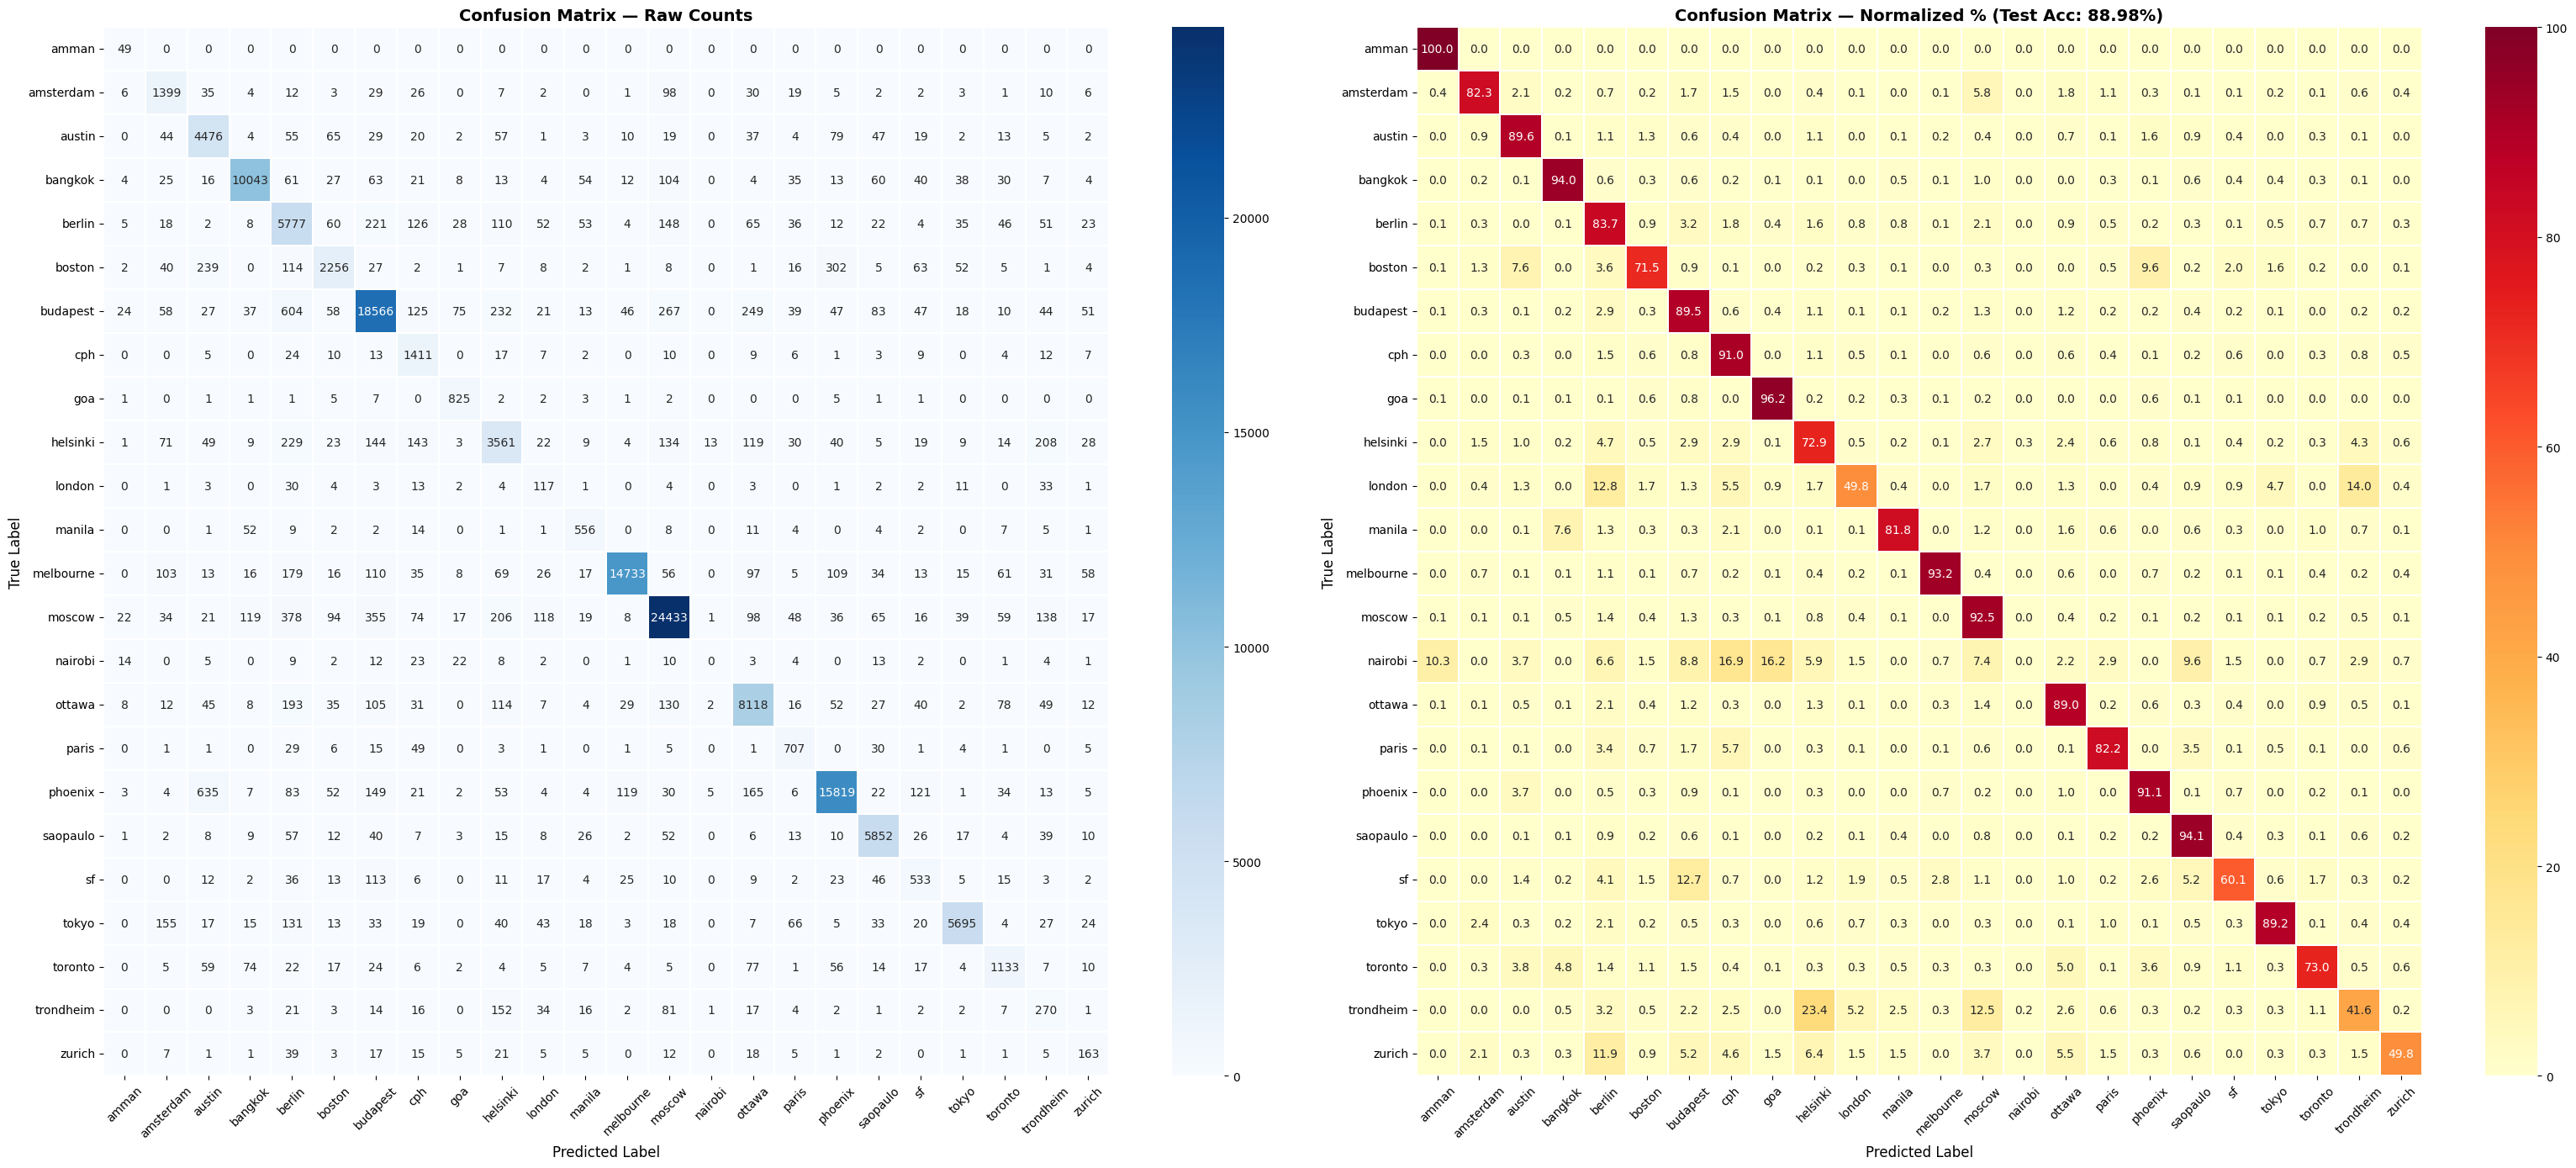

 Confusion matrix saved


In [31]:
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(32, 14))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            xticklabels=CITY_NAMES, yticklabels=CITY_NAMES,
            cmap='Blues', linewidths=0.3)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Normalized %
sns.heatmap(cm_norm, annot=True, fmt='.1f', ax=axes[1],
            xticklabels=CITY_NAMES, yticklabels=CITY_NAMES,
            cmap='YlOrRd', linewidths=0.3, vmin=0, vmax=100)
axes[1].set_title(f'Confusion Matrix — Normalized % (Test Acc: {test_acc:.2f}%)',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrix saved")

 Per-City Accuracy Bar Plot

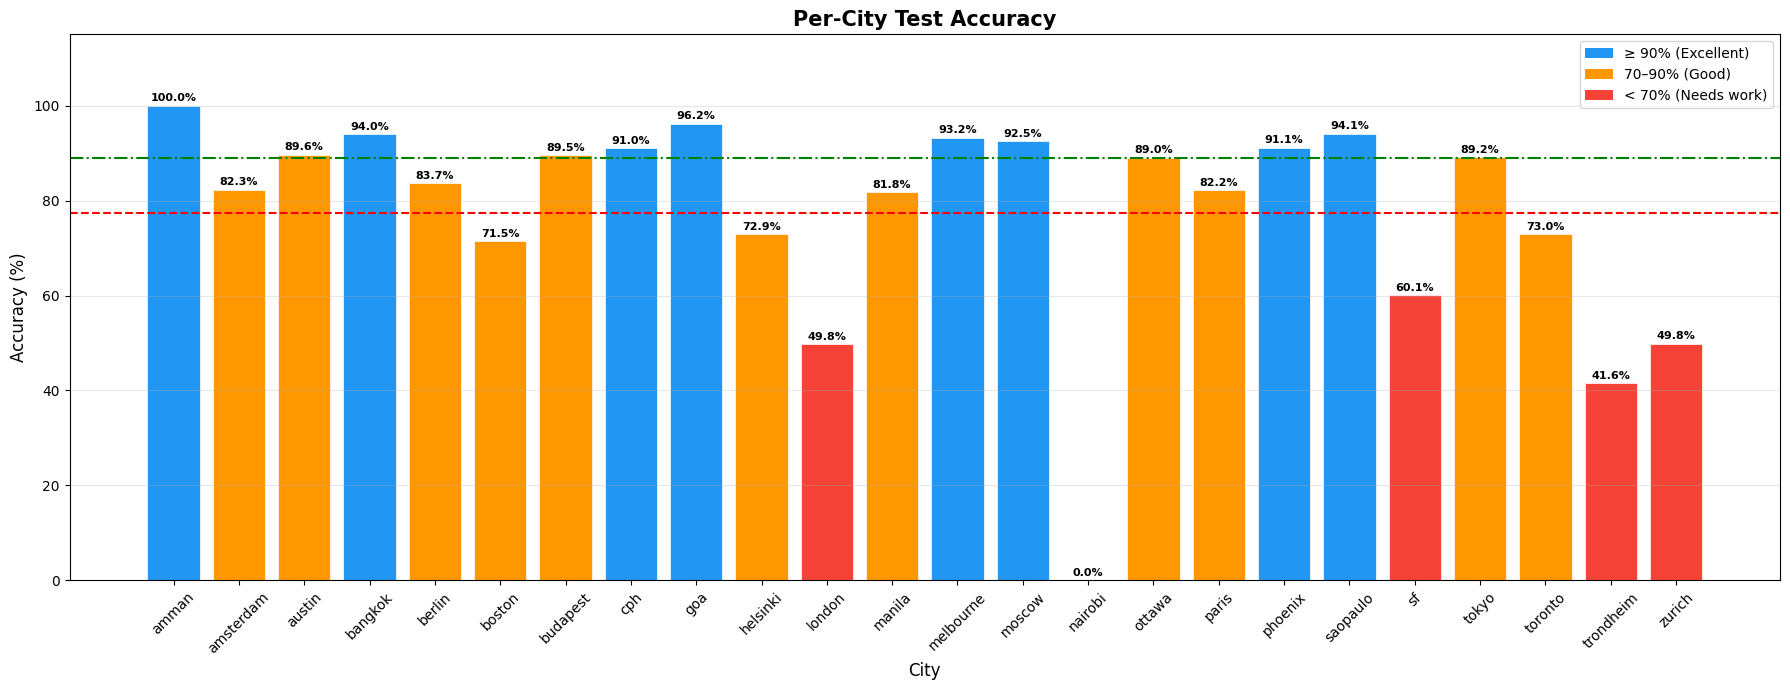

 Per-city accuracy plot saved


In [32]:
fig, ax = plt.subplots(figsize=(18, 7))

colors = ['#2196F3' if acc >= 90 else '#FF9800' if acc >= 70 else '#F44336'
          for acc in per_city_acc]

bars = ax.bar(CITY_NAMES, per_city_acc, color=colors, edgecolor='white', linewidth=0.5)

for bar, acc in zip(bars, per_city_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.axhline(y=np.mean(per_city_acc), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean: {np.mean(per_city_acc):.1f}%')
ax.axhline(y=test_acc, color='green', linestyle='-.',
           linewidth=1.5, label=f'Overall Acc: {test_acc:.2f}%')

ax.set_title('Per-City Test Accuracy', fontsize=15, fontweight='bold')
ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 115)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='≥ 90% (Excellent)'),
    Patch(facecolor='#FF9800', label='70–90% (Good)'),
    Patch(facecolor='#F44336', label='< 70% (Needs work)'),
]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][2:],
          fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'per_city_accuracy.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" Per-city accuracy plot saved")

Precision / Recall / F1 Grouped Bar

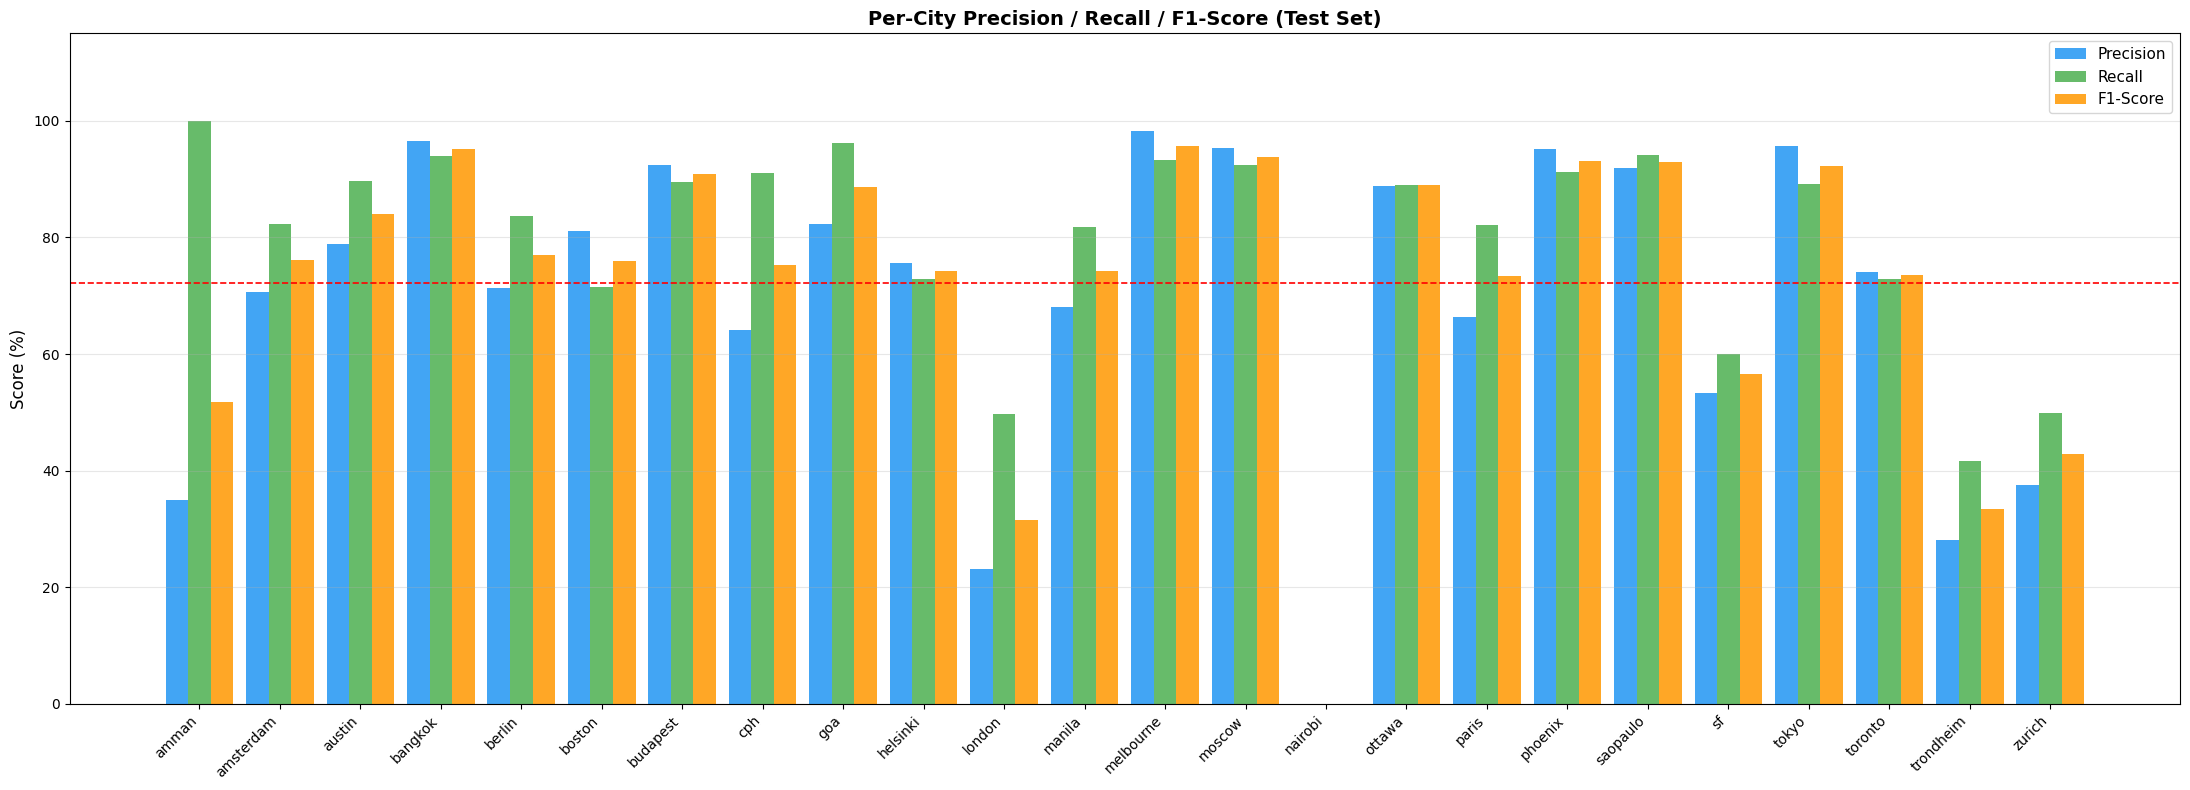

 Precision/Recall/F1 plot saved


In [33]:
x     = np.arange(len(CITY_NAMES))
width = 0.28

fig, ax = plt.subplots(figsize=(22, 8))

ax.bar(x - width, precision*100, width, label='Precision', color='#2196F3', alpha=0.85)
ax.bar(x,          recall*100,   width, label='Recall',    color='#4CAF50', alpha=0.85)
ax.bar(x + width,  f1*100,       width, label='F1-Score',  color='#FF9800', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CITY_NAMES, rotation=45, ha='right')
ax.set_title('Per-City Precision / Recall / F1-Score (Test Set)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

ax.axhline(y=mac_f*100, color='red', linestyle='--',
           linewidth=1.2, label=f'Macro F1: {mac_f*100:.1f}%')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'precision_recall_f1.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" Precision/Recall/F1 plot saved")

Top-K Accuracy Plot

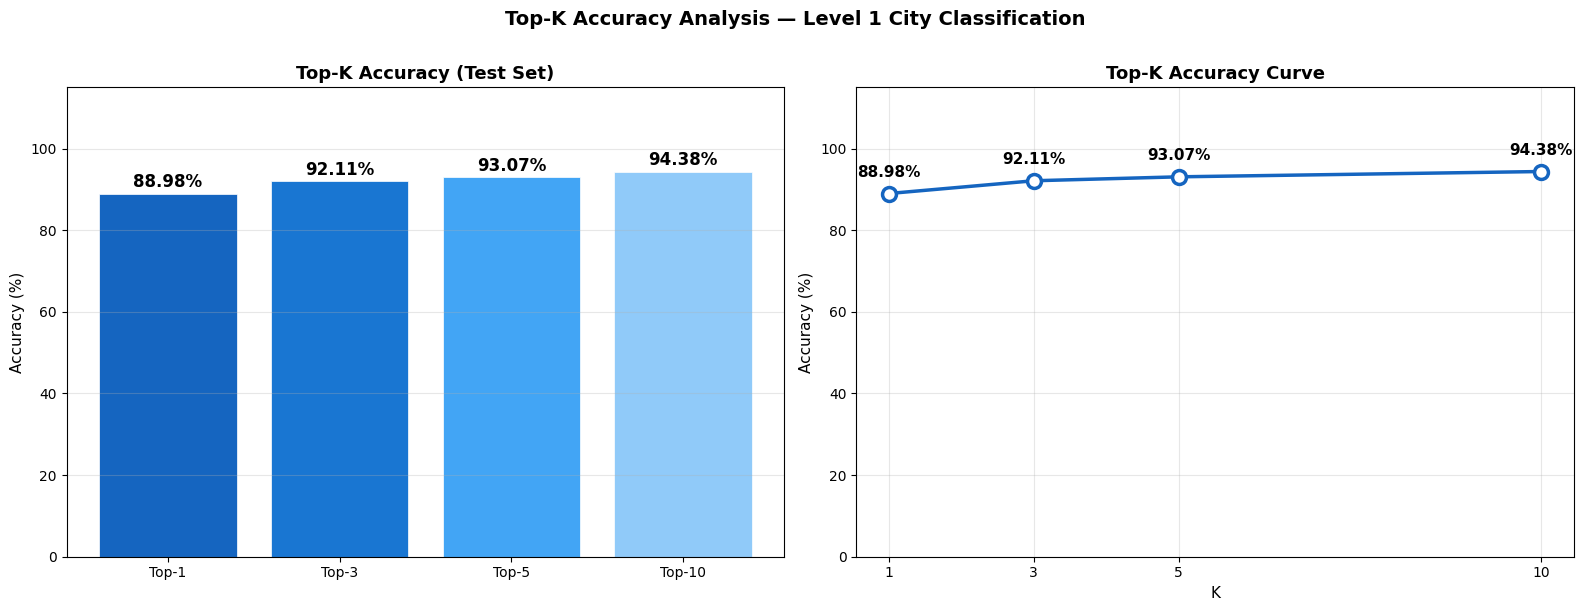

 Top-K accuracy plot saved


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
k_vals   = [1, 3, 5, 10]
k_scores = [top1, top3, top5, top10]
colors_k = ['#1565C0', '#1976D2', '#42A5F5', '#90CAF9']

bars = axes[0].bar([f'Top-{k}' for k in k_vals], k_scores,
                    color=colors_k, edgecolor='white', linewidth=0.5)
for bar, score in zip(bars, k_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{score:.2f}%', ha='center', va='bottom',
                 fontsize=12, fontweight='bold')
axes[0].set_title('Top-K Accuracy (Test Set)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0].set_ylim(0, 115)
axes[0].grid(axis='y', alpha=0.3)

# Line chart
axes[1].plot(k_vals, k_scores, 'o-', color='#1565C0',
             linewidth=2.5, markersize=10, markerfacecolor='white',
             markeredgewidth=2.5)
for k, s in zip(k_vals, k_scores):
    axes[1].annotate(f'{s:.2f}%', (k, s),
                     textcoords='offset points', xytext=(0, 12),
                     ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Top-K Accuracy Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('K', fontsize=11)
axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].set_xticks(k_vals)
axes[1].set_ylim(0, 115)
axes[1].grid(alpha=0.3)

plt.suptitle('Top-K Accuracy Analysis — Level 1 City Classification',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'topk_accuracy.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" Top-K accuracy plot saved")

Most Confused Cities Plot

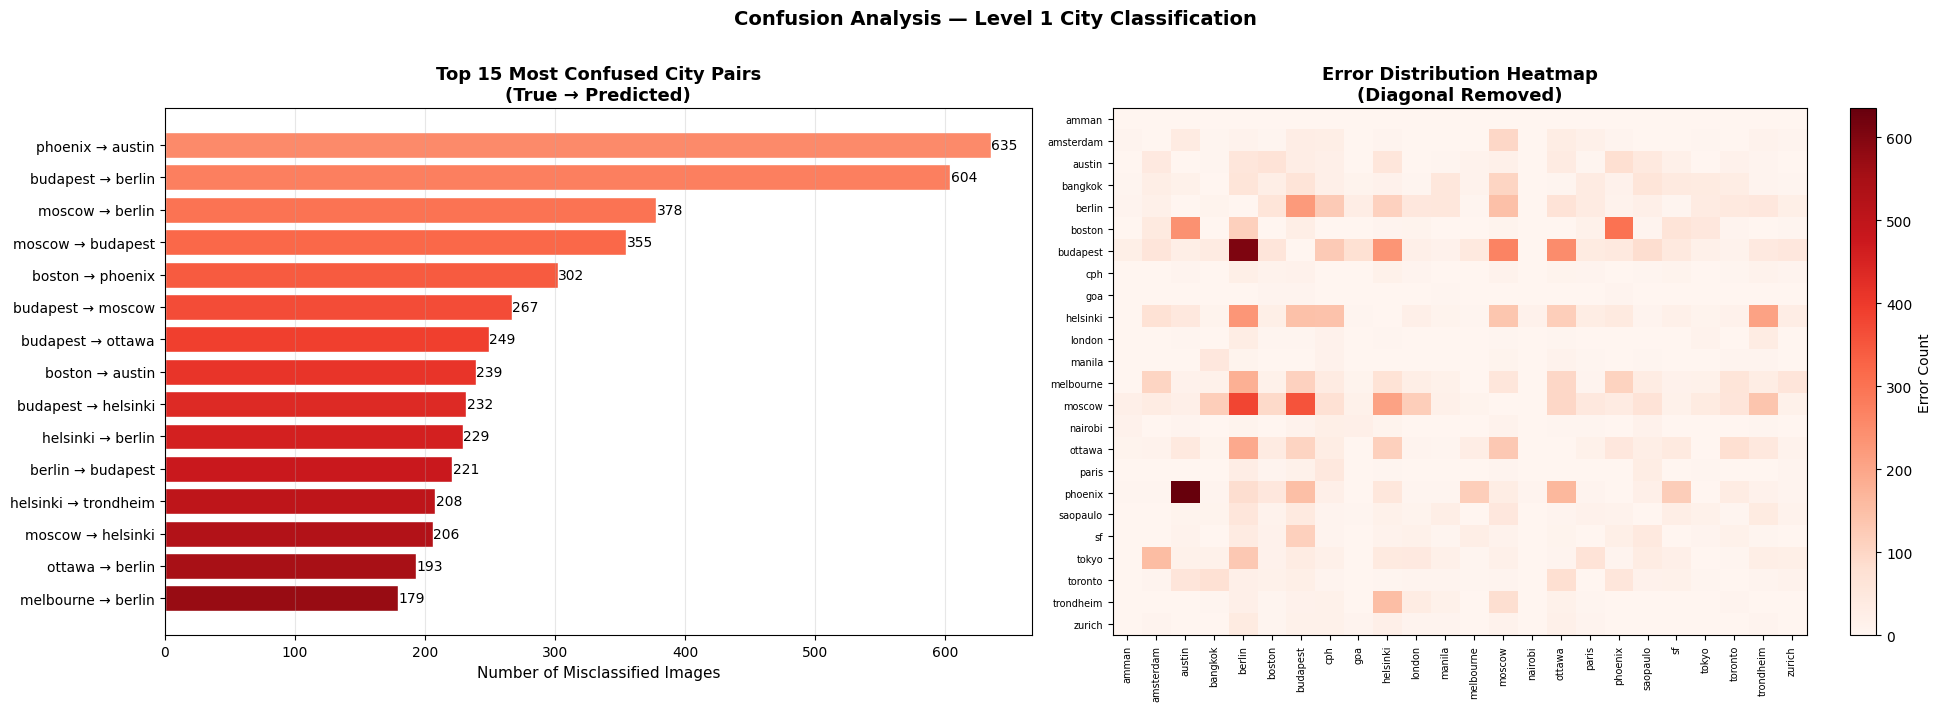


Top 10 Most Confused Pairs:
True         Predicted       Count
phoenix      austin            635
budapest     berlin            604
moscow       berlin            378
moscow       budapest          355
boston       phoenix           302
budapest     moscow            267
budapest     ottawa            249
boston       austin            239
budapest     helsinki          232
helsinki     berlin            229
 Confusion analysis saved


In [35]:
cm_raw = confusion_matrix(test_labels, test_preds)
np.fill_diagonal(cm_raw, 0)

confused = []
for i in range(len(CITY_NAMES)):
    for j in range(len(CITY_NAMES)):
        if cm_raw[i, j] > 0:
            confused.append((cm_raw[i, j], CITY_NAMES[i], CITY_NAMES[j]))
confused.sort(reverse=True)
top15 = confused[:15]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Bar chart — top 15 confused pairs
labels_conf  = [f"{t} → {p}" for _, t, p in top15]
counts_conf  = [c for c, _, _ in top15]
colors_conf  = plt.cm.Reds(np.linspace(0.4, 0.9, len(top15)))

axes[0].barh(labels_conf[::-1], counts_conf[::-1],
             color=colors_conf[::-1], edgecolor='white')
for i, (c, lbl) in enumerate(zip(counts_conf[::-1], labels_conf[::-1])):
    axes[0].text(c + 0.3, i, str(c), va='center', fontsize=10)
axes[0].set_title('Top 15 Most Confused City Pairs\n(True → Predicted)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Misclassified Images', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)

# Heatmap of error counts (off-diagonal only)
axes[1].imshow(cm_raw, cmap='Reds', aspect='auto')
axes[1].set_xticks(range(len(CITY_NAMES)))
axes[1].set_yticks(range(len(CITY_NAMES)))
axes[1].set_xticklabels(CITY_NAMES, rotation=90, fontsize=7)
axes[1].set_yticklabels(CITY_NAMES, fontsize=7)
axes[1].set_title('Error Distribution Heatmap\n(Diagonal Removed)',
                  fontsize=13, fontweight='bold')
plt.colorbar(axes[1].images[0], ax=axes[1], label='Error Count')

plt.suptitle('Confusion Analysis — Level 1 City Classification',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'most_confused_cities.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Most Confused Pairs:")
print(f"{'True':<12} {'Predicted':<12} {'Count':>8}")

for count, true_c, pred_c in confused[:10]:
    print(f"{true_c:<12} {pred_c:<12} {count:>8,}")
print(" Confusion analysis saved")

 Train vs Test Comparison Plot

Train Sample (20k) Results
Loss    : 0.6938
Accuracy: 97.67%


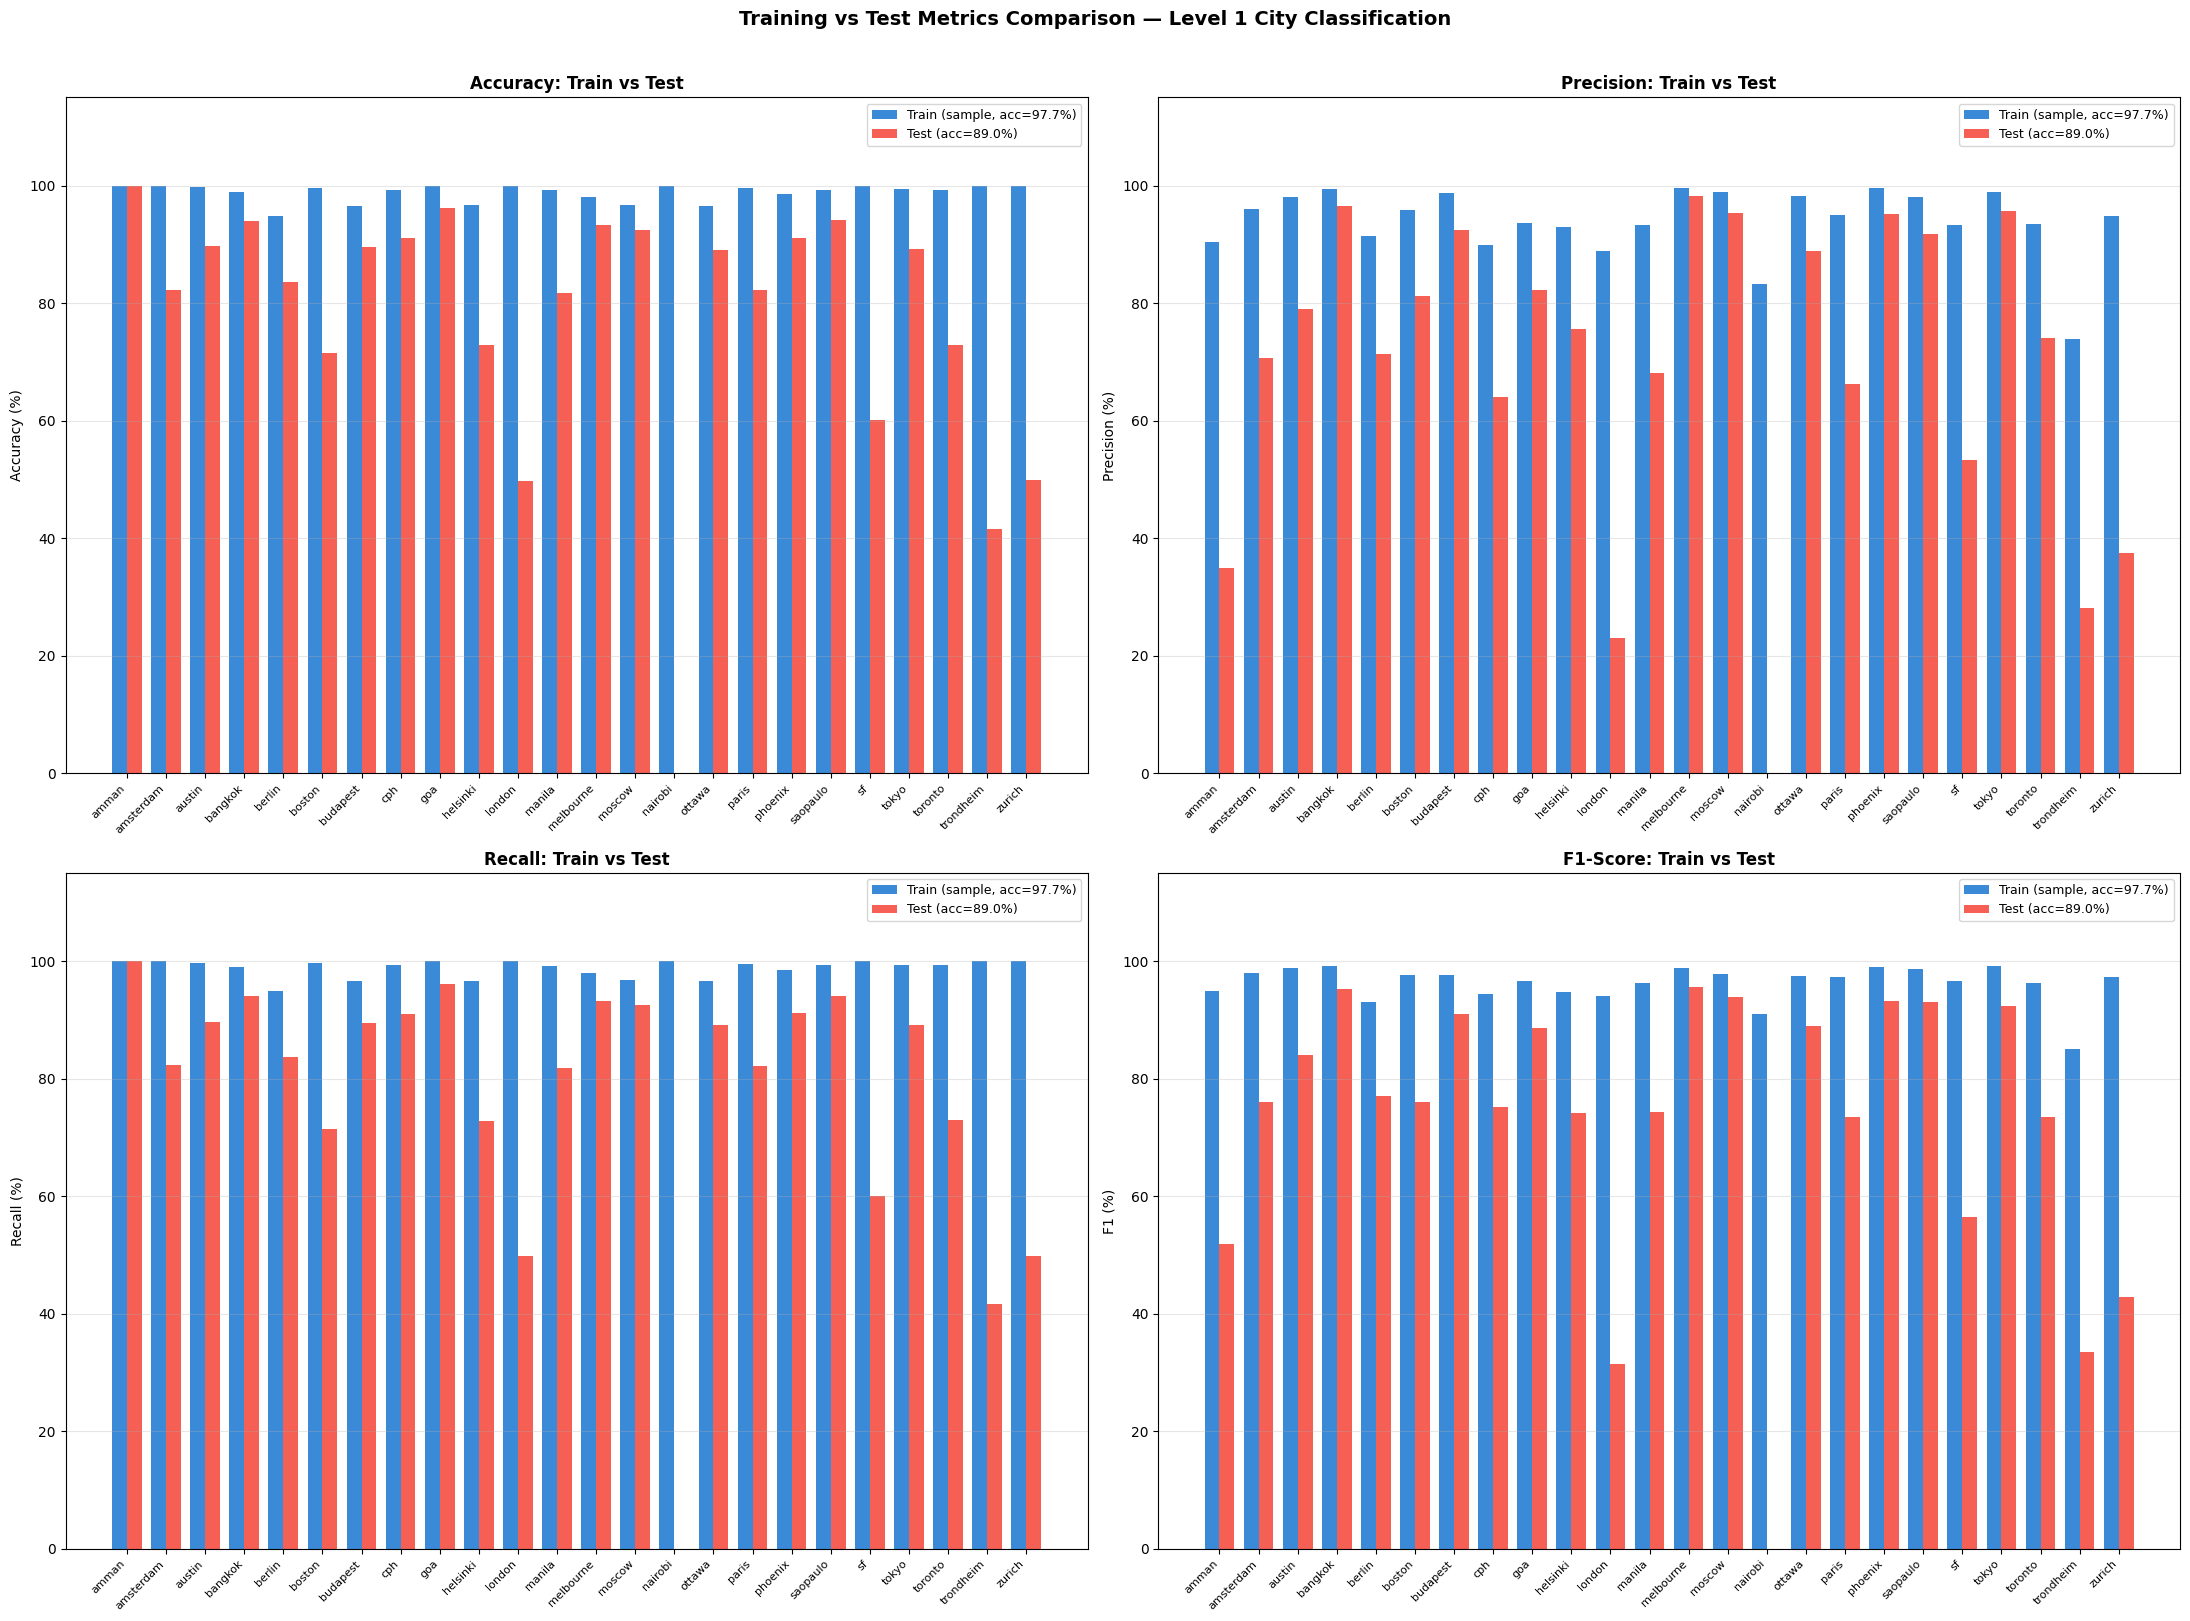

 Train vs Test comparison saved


In [36]:

from torch.utils.data import SubsetRandomSampler

sample_idx    = np.random.choice(len(train_df), size=min(20000, len(train_df)), replace=False)
sample_ds     = CityDataset(train_df.iloc[sample_idx].reset_index(drop=True), transform=transform_val)
sample_loader = DataLoader(sample_ds, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=0)

train_preds_s, train_labels_s, train_probs_s, train_acc_s, _ = evaluate_split(
    sample_loader, "Train Sample (20k)"
)

prec_tr, rec_tr, f1_tr, _ = precision_recall_fscore_support(
    train_labels_s, train_preds_s, average=None,
    labels=list(range(len(CITY_NAMES)))
)
prec_te, rec_te, f1_te, _ = precision_recall_fscore_support(
    test_labels, test_preds, average=None,
    labels=list(range(len(CITY_NAMES)))
)
acc_tr = [np.mean(train_preds_s[train_labels_s == i] == i)*100
          if (train_labels_s == i).sum() > 0 else 0.0
          for i in range(len(CITY_NAMES))]

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
x = np.arange(len(CITY_NAMES))
w = 0.38

def comparison_bar(ax, train_vals, test_vals, title, ylabel):
    ax.bar(x - w/2, train_vals, w, label=f'Train (sample, acc={train_acc_s:.1f}%)',
           color='#1976D2', alpha=0.85)
    ax.bar(x + w/2, test_vals,  w, label=f'Test (acc={test_acc:.1f}%)',
           color='#F44336', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(CITY_NAMES, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(0, 115)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

comparison_bar(axes[0,0], acc_tr,        per_city_acc,   'Accuracy: Train vs Test', 'Accuracy (%)')
comparison_bar(axes[0,1], prec_tr*100,   prec_te*100,    'Precision: Train vs Test', 'Precision (%)')
comparison_bar(axes[1,0], rec_tr*100,    rec_te*100,     'Recall: Train vs Test',    'Recall (%)')
comparison_bar(axes[1,1], f1_tr*100,     f1_te*100,      'F1-Score: Train vs Test',  'F1 (%)')

plt.suptitle('Training vs Test Metrics Comparison — Level 1 City Classification',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'train_vs_test_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" Train vs Test comparison saved")

Actual vs Predicted Distribution

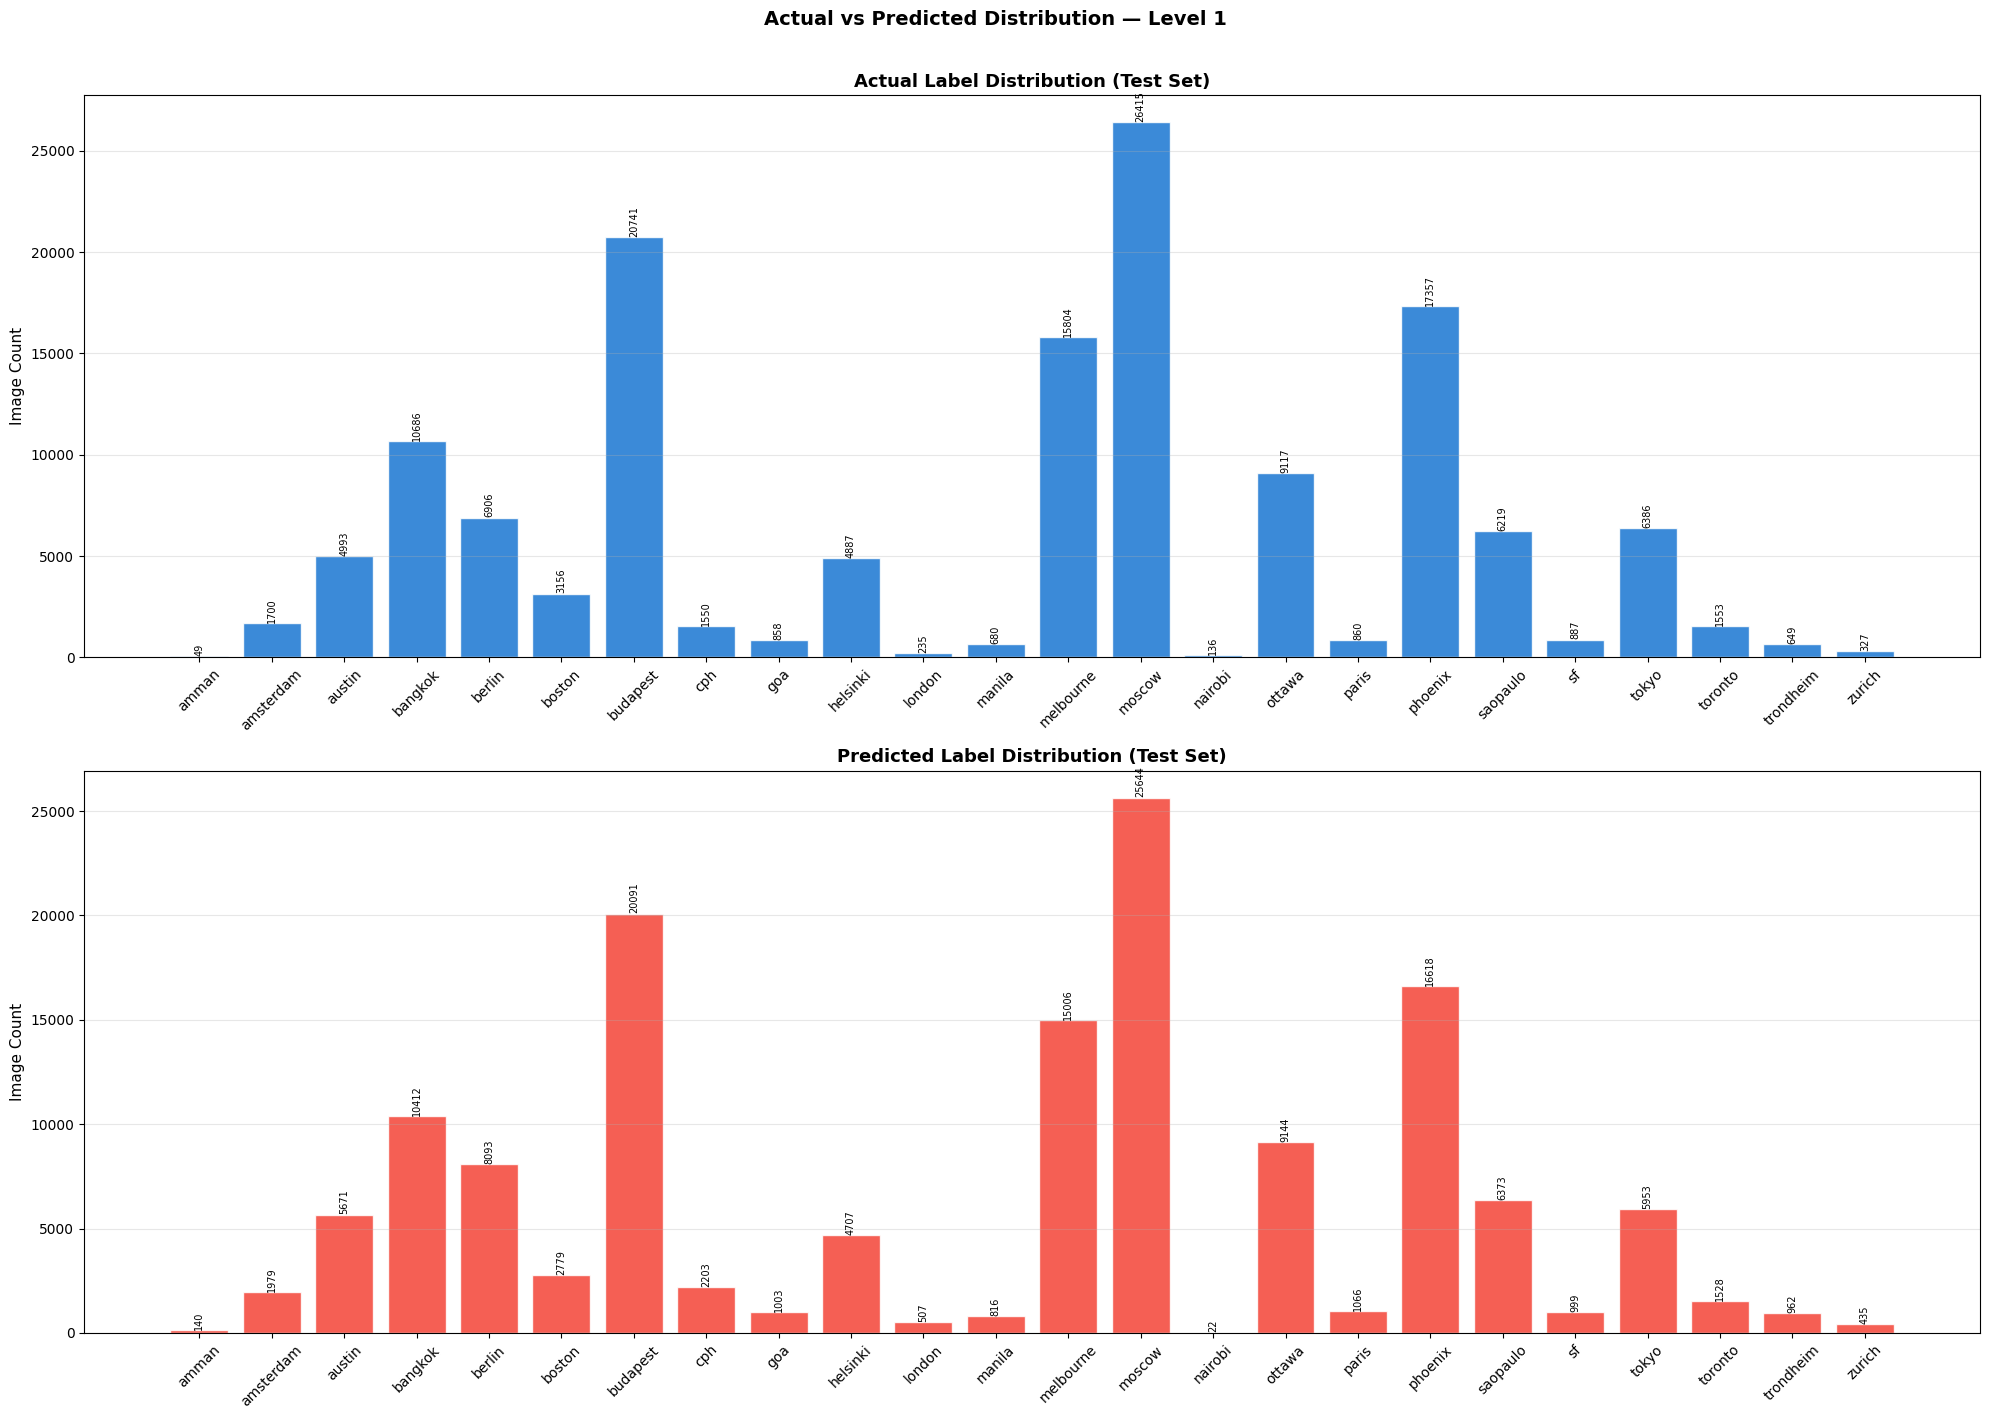

 Distribution comparison saved


In [37]:
fig, axes = plt.subplots(2, 1, figsize=(20, 14))

# Actual distribution
actual_counts = [int((test_labels == i).sum()) for i in range(len(CITY_NAMES))]
axes[0].bar(CITY_NAMES, actual_counts, color='#1976D2', alpha=0.85, edgecolor='white')
for i, c in enumerate(actual_counts):
    axes[0].text(i, c + 5, str(c), ha='center', va='bottom', fontsize=7, rotation=90)
axes[0].set_title('Actual Label Distribution (Test Set)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Image Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Predicted distribution
pred_counts = [int((test_preds == i).sum()) for i in range(len(CITY_NAMES))]
axes[1].bar(CITY_NAMES, pred_counts, color='#F44336', alpha=0.85, edgecolor='white')
for i, c in enumerate(pred_counts):
    axes[1].text(i, c + 5, str(c), ha='center', va='bottom', fontsize=7, rotation=90)
axes[1].set_title('Predicted Label Distribution (Test Set)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Image Count', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Actual vs Predicted Distribution — Level 1',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'actual_vs_predicted_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" Distribution comparison saved")

Error Distribution Plot

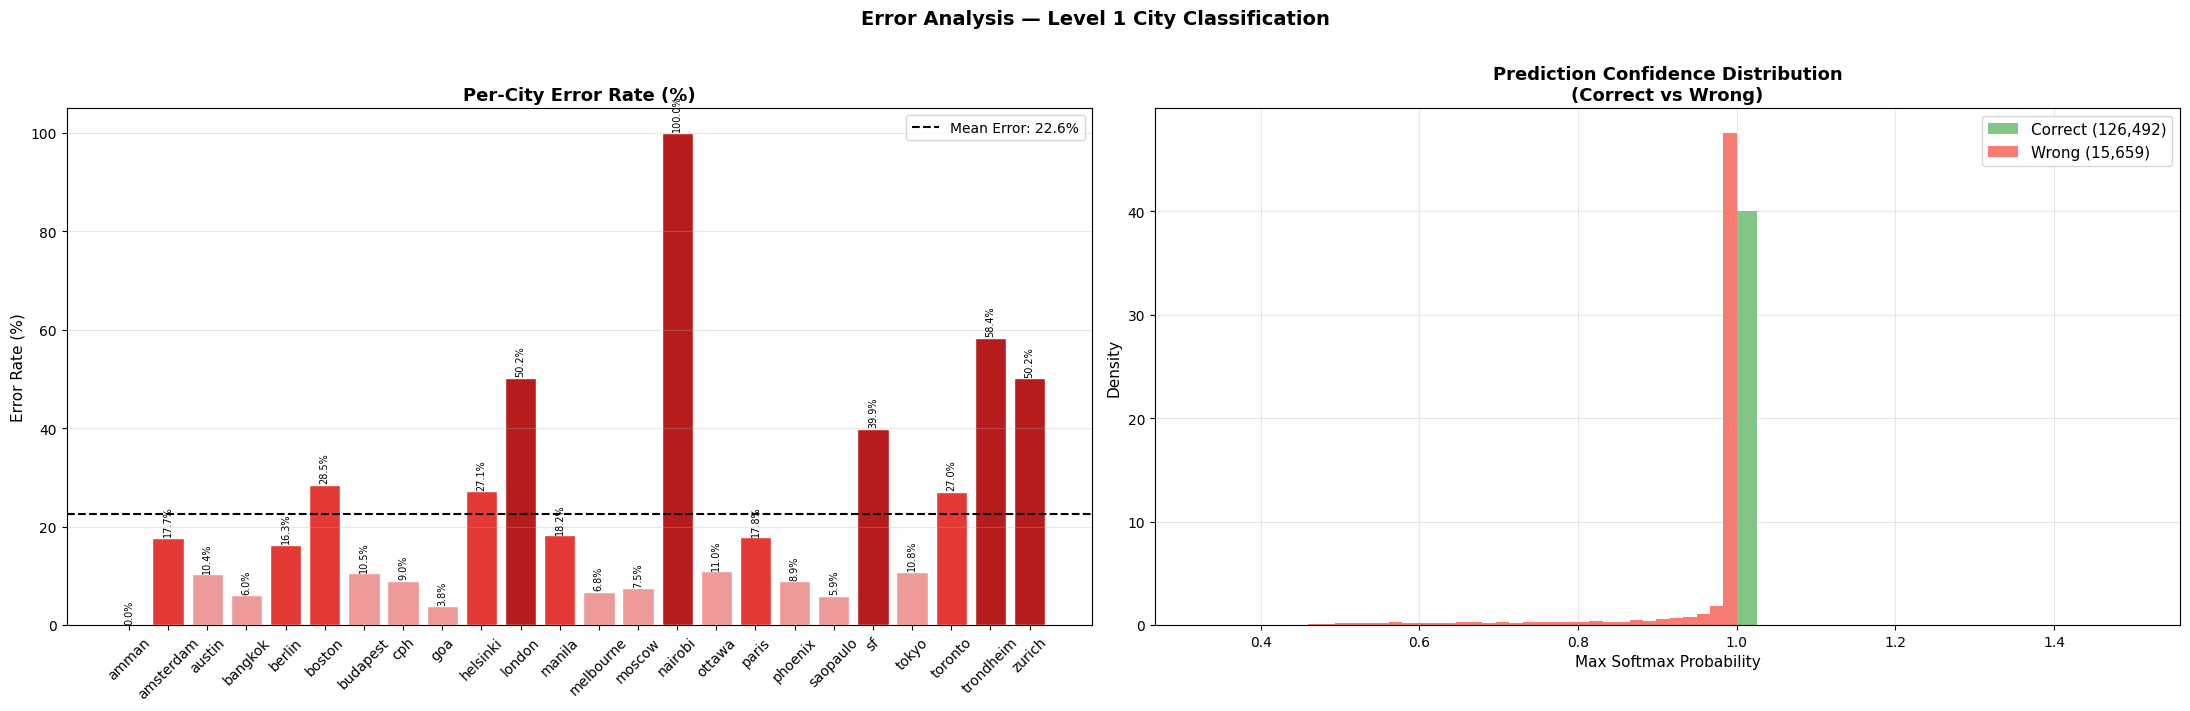

 Error distribution plot saved


In [38]:
# Per-city error rates
error_rates  = [100 - a for a in per_city_acc]
error_counts = [int((test_labels == i).sum()) - int(np.sum((test_preds == i) & (test_labels == i)))
                for i in range(len(CITY_NAMES))]

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

# Error rate %
colors_err = ['#B71C1C' if e > 30 else '#E53935' if e > 15 else '#EF9A9A'
              for e in error_rates]
axes[0].bar(CITY_NAMES, error_rates, color=colors_err, edgecolor='white')
for i, e in enumerate(error_rates):
    axes[0].text(i, e + 0.3, f'{e:.1f}%', ha='center', va='bottom', fontsize=7, rotation=90)
axes[0].set_title('Per-City Error Rate (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Error Rate (%)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=np.mean(error_rates), color='black', linestyle='--',
                label=f'Mean Error: {np.mean(error_rates):.1f}%')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Confidence of correct vs wrong predictions
correct_mask   = test_preds == test_labels
correct_conf   = test_probs[correct_mask, test_labels[correct_mask]].max(axis=-1) if correct_mask.any() else []
wrong_conf     = test_probs[~correct_mask].max(axis=-1) if (~correct_mask).any() else []

axes[1].hist(correct_conf, bins=40, alpha=0.7, color='#4CAF50',
             label=f'Correct ({correct_mask.sum():,})', density=True)
axes[1].hist(wrong_conf,   bins=40, alpha=0.7, color='#F44336',
             label=f'Wrong ({(~correct_mask).sum():,})', density=True)
axes[1].set_title('Prediction Confidence Distribution\n(Correct vs Wrong)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Max Softmax Probability', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Error Analysis — Level 1 City Classification',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'error_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" Error distribution plot saved")

Final Summary Dashboard

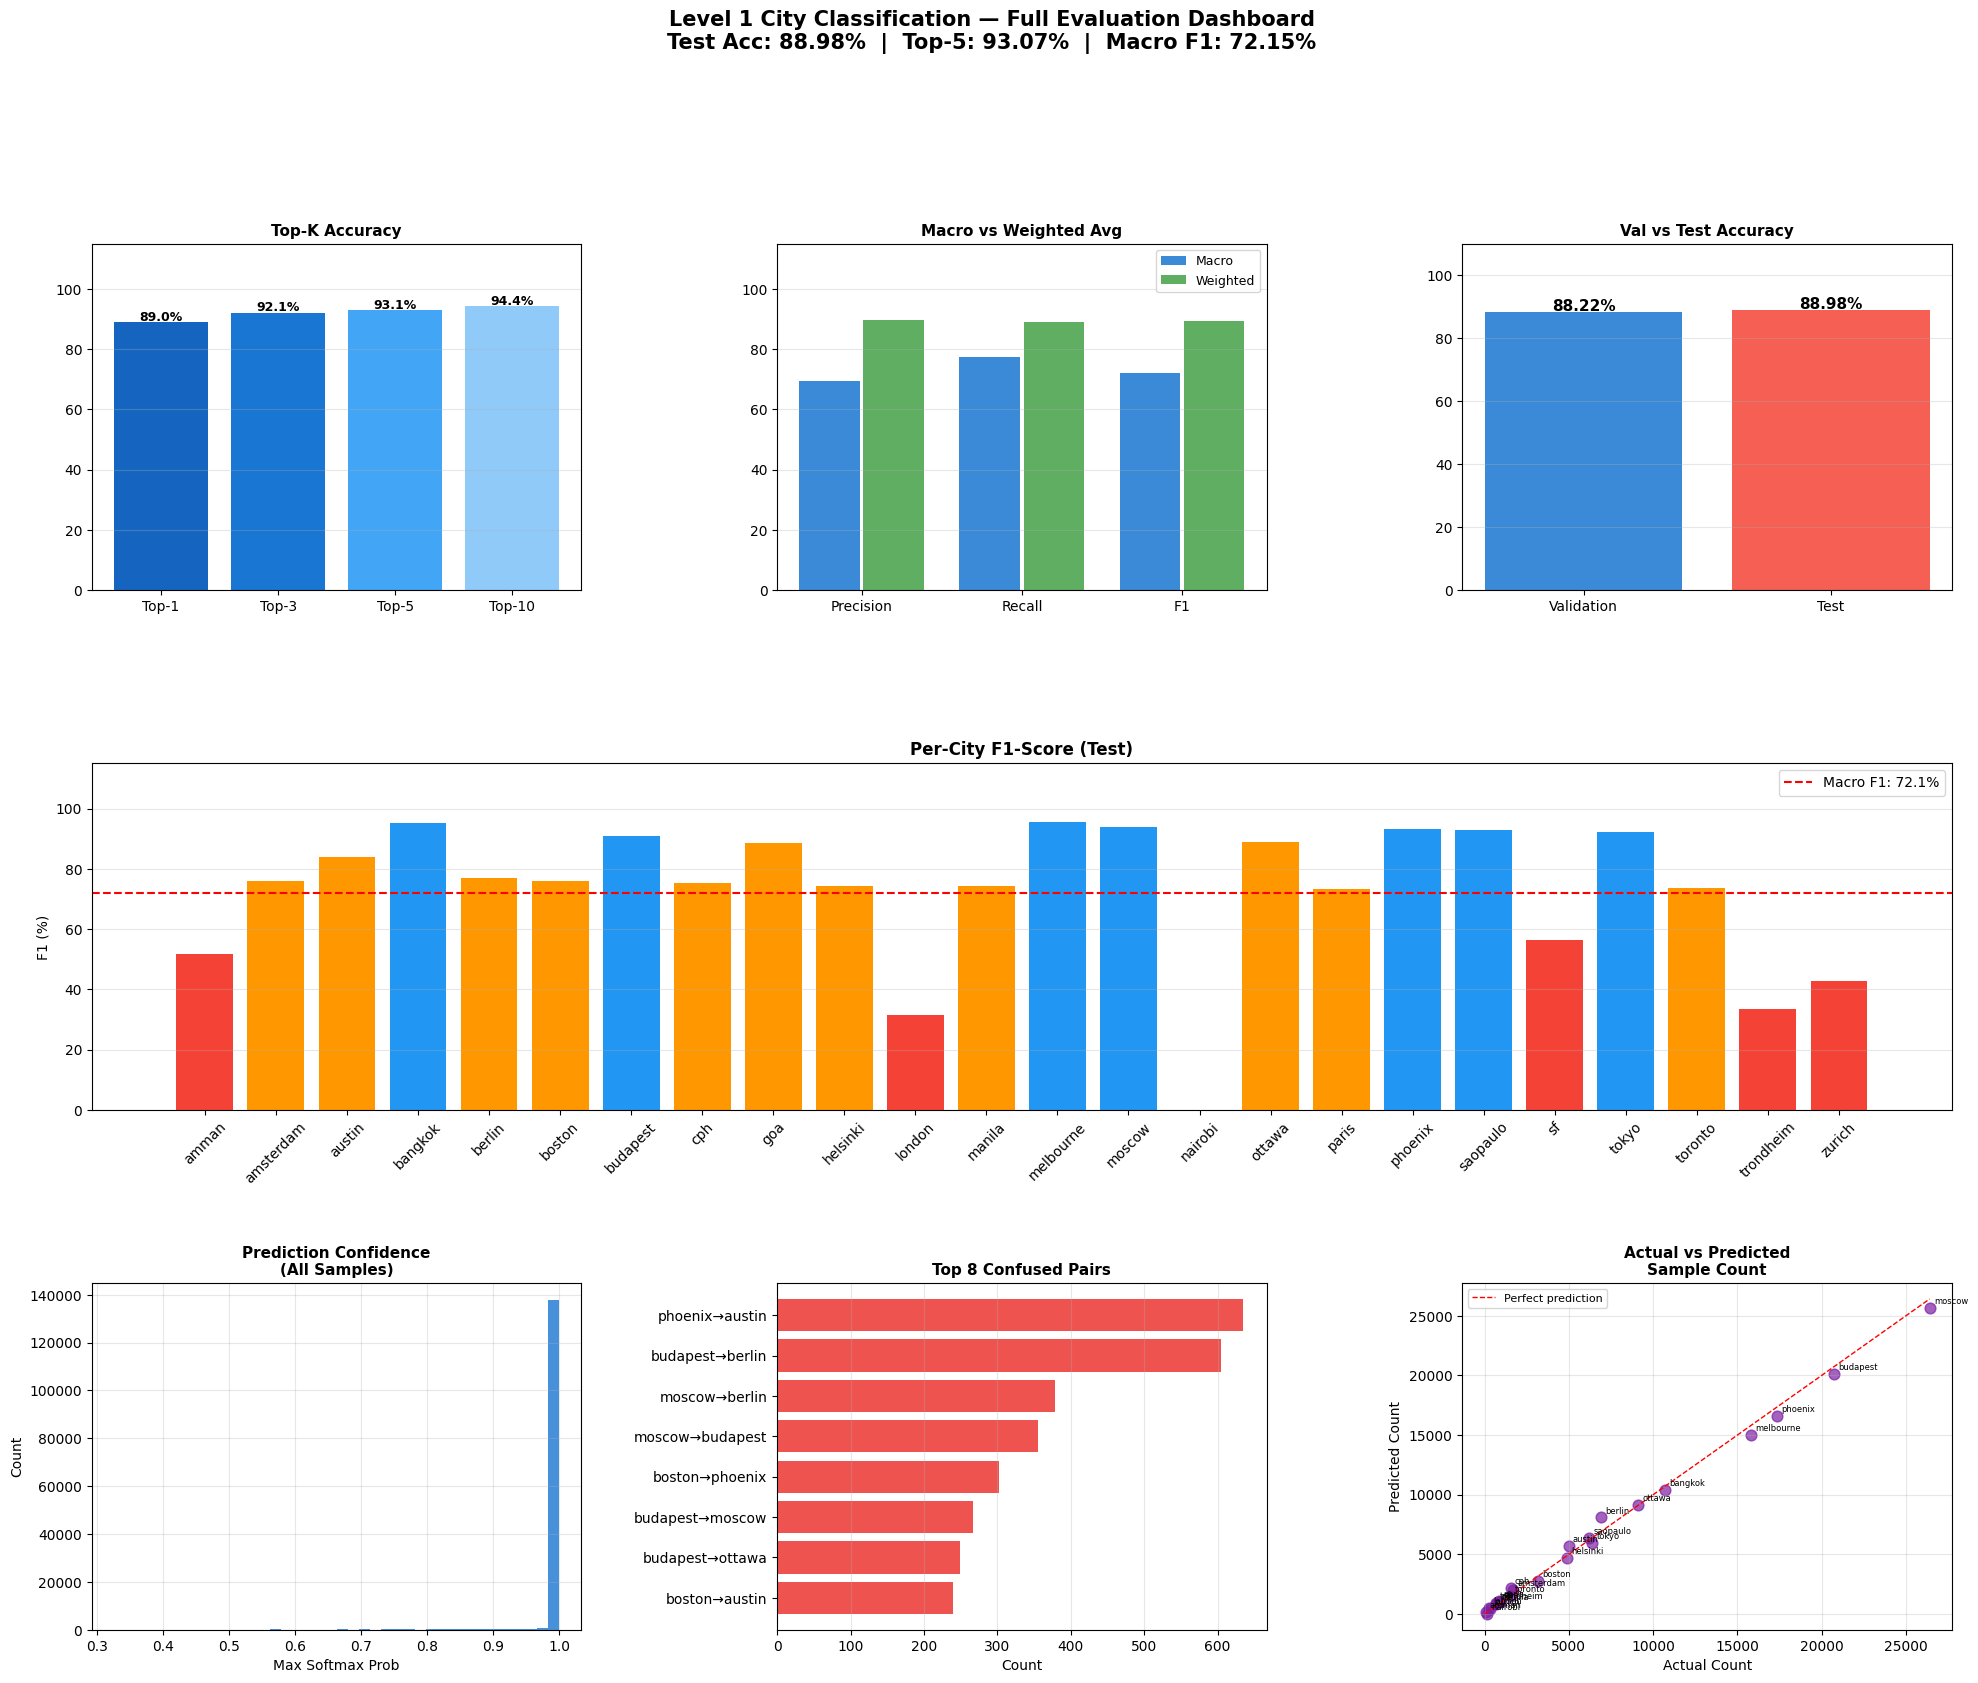

 Full dashboard saved


In [39]:
fig = plt.figure(figsize=(24, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# 1. Top-K Accuracy
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(['Top-1', 'Top-3', 'Top-5', 'Top-10'],
        [top1, top3, top5, top10],
        color=['#1565C0','#1976D2','#42A5F5','#90CAF9'])
for i, v in enumerate([top1, top3, top5, top10]):
    ax1.text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax1.set_title('Top-K Accuracy', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 115)
ax1.grid(axis='y', alpha=0.3)

# 2. Macro / Weighted Averages
ax2 = fig.add_subplot(gs[0, 1])
cats   = ['Precision', 'Recall', 'F1']
macro  = [mac_p*100, mac_r*100, mac_f*100]
weighted = [wgt_p*100, wgt_r*100, wgt_f*100]
xp = np.arange(3)
ax2.bar(xp-0.2, macro,    0.38, label='Macro',    color='#1976D2', alpha=0.85)
ax2.bar(xp+0.2, weighted, 0.38, label='Weighted', color='#43A047', alpha=0.85)
ax2.set_xticks(xp); ax2.set_xticklabels(cats)
ax2.set_title('Macro vs Weighted Avg', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 115); ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

# 3. Val vs Test Accuracy
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(['Validation', 'Test'], [val_acc, test_acc],
        color=['#1976D2', '#F44336'], alpha=0.85)
ax3.text(0, val_acc+0.5, f'{val_acc:.2f}%', ha='center', fontsize=11, fontweight='bold')
ax3.text(1, test_acc+0.5, f'{test_acc:.2f}%', ha='center', fontsize=11, fontweight='bold')
ax3.set_title('Val vs Test Accuracy', fontsize=11, fontweight='bold')
ax3.set_ylim(0, 110); ax3.grid(axis='y', alpha=0.3)

# 4. Per-city F1
ax4 = fig.add_subplot(gs[1, :])
colors_f1 = ['#2196F3' if v >= 90 else '#FF9800' if v >= 70 else '#F44336'
              for v in f1*100]
ax4.bar(CITY_NAMES, f1*100, color=colors_f1)
ax4.axhline(y=mac_f*100, color='red', linestyle='--',
            label=f'Macro F1: {mac_f*100:.1f}%')
ax4.set_title('Per-City F1-Score (Test)', fontsize=12, fontweight='bold')
ax4.set_ylabel('F1 (%)')
ax4.tick_params(axis='x', rotation=45)
ax4.set_ylim(0, 115); ax4.legend(); ax4.grid(axis='y', alpha=0.3)

# 5. Confidence histogram
ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(test_probs.max(axis=1), bins=40, color='#1976D2', alpha=0.8)
ax5.set_title('Prediction Confidence\n(All Samples)', fontsize=11, fontweight='bold')
ax5.set_xlabel('Max Softmax Prob'); ax5.set_ylabel('Count')
ax5.grid(alpha=0.3)

# 6. Top confused pairs
ax6 = fig.add_subplot(gs[2, 1])
top8_conf  = confused[:8]
lbl_conf   = [f"{t}→{p}" for _, t, p in top8_conf]
cnt_conf   = [c for c, _, _ in top8_conf]
ax6.barh(lbl_conf[::-1], cnt_conf[::-1], color='#EF5350')
ax6.set_title('Top 8 Confused Pairs', fontsize=11, fontweight='bold')
ax6.set_xlabel('Count')
ax6.grid(axis='x', alpha=0.3)

# 7. Actual vs Predicted counts scatter
ax7 = fig.add_subplot(gs[2, 2])
ax7.scatter(actual_counts, pred_counts, alpha=0.7, color='#7B1FA2', s=60)
for i, city in enumerate(CITY_NAMES):
    ax7.annotate(city, (actual_counts[i], pred_counts[i]), fontsize=6,
                 xytext=(3,3), textcoords='offset points')
max_val = max(max(actual_counts), max(pred_counts))
ax7.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect prediction')
ax7.set_title('Actual vs Predicted\nSample Count', fontsize=11, fontweight='bold')
ax7.set_xlabel('Actual Count'); ax7.set_ylabel('Predicted Count')
ax7.legend(fontsize=8); ax7.grid(alpha=0.3)

plt.suptitle(f'Level 1 City Classification — Full Evaluation Dashboard\n'
             f'Test Acc: {test_acc:.2f}%  |  Top-5: {top5:.2f}%  |  Macro F1: {mac_f*100:.2f}%',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig(os.path.join(RESULTS_DIR, 'evaluation_dashboard.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" Full dashboard saved")

Save All Results Summary

In [40]:
summary = {
    'Metric'  : ['Val Loss', 'Val Accuracy', 'Test Loss', 'Test Accuracy',
                 'Top-3 Accuracy', 'Top-5 Accuracy', 'Top-10 Accuracy',
                 'Macro Precision', 'Macro Recall', 'Macro F1',
                 'Weighted Precision', 'Weighted Recall', 'Weighted F1'],
    'Value'   : [f'{val_loss:.4f}', f'{val_acc:.2f}%', f'{test_loss:.4f}',
                 f'{test_acc:.2f}%', f'{top3:.2f}%', f'{top5:.2f}%',
                 f'{top10:.2f}%', f'{mac_p*100:.2f}%', f'{mac_r*100:.2f}%',
                 f'{mac_f*100:.2f}%', f'{wgt_p*100:.2f}%',
                 f'{wgt_r*100:.2f}%', f'{wgt_f*100:.2f}%']
}
summary_df = pd.DataFrame(summary)
summary_df.to_csv(os.path.join(RESULTS_DIR, 'evaluation_summary.csv'), index=False)

print("\n" + "="*45)
print("FINAL EVALUATION SUMMARY")
print("="*45)
for _, row in summary_df.iterrows():
    print(f"{row['Metric']:<22}: {row['Value']}")
print(f"\n✅ All results saved to: {RESULTS_DIR}")
print("\nFiles saved:")
for f in sorted(os.listdir(RESULTS_DIR)):
    size = os.path.getsize(os.path.join(RESULTS_DIR, f)) / 1024
    print(f"  {f:<45} {size:>6.1f} KB")

torch.cuda.empty_cache()
gc.collect()
print("\n Evaluation Complete!")


FINAL EVALUATION SUMMARY
Val Loss              : 4.9314
Val Accuracy          : 88.22%
Test Loss             : 4.5301
Test Accuracy         : 88.98%
Top-3 Accuracy        : 92.11%
Top-5 Accuracy        : 93.07%
Top-10 Accuracy       : 94.38%
Macro Precision       : 69.31%
Macro Recall          : 77.42%
Macro F1              : 72.15%
Weighted Precision    : 89.81%
Weighted Recall       : 88.98%
Weighted F1           : 89.26%

✅ All results saved to: C:\Level 3 pytorch\results\level1

Files saved:
  actual_vs_predicted_distribution.png           246.8 KB
  confusion_matrix.png                           580.4 KB
  error_distribution.png                         170.2 KB
  evaluation_dashboard.png                       323.6 KB
  evaluation_summary.csv                           0.3 KB
  level1_arc_history_resumed.csv                   0.5 KB
  most_confused_cities.png                       203.7 KB
  per_city_accuracy.png                          138.8 KB
  per_city_metrics.csv            

In [ ]:

print("Per-City Test Accuracy")

for i, city in enumerate(CITY_NAMES):
    mask = test_labels == i
    if mask.sum() == 0:
        continue
    city_acc = np.mean(test_preds[mask] == i) * 100
    bar      = "█ " * int(city_acc / 5)
    print(f"{city:<12}: {city_acc:>6.2f}%  {bar}")

Top-K Accuracy

In [ ]:
def top_k_accuracy(loader, k=5):
    model_l1.eval()
    arcface_l1.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.amp.autocast('cuda'):
                emb     = model_l1(imgs)
                outputs = arcface_l1(emb, labels)
            topk_preds = outputs.topk(k, dim=1).indices
            correct   += (topk_preds == labels.unsqueeze(1)).any(dim=1).sum().item()
            total     += labels.size(0)

    return correct / total * 100

top3_acc = top_k_accuracy(test_loader, k=3)
top5_acc = top_k_accuracy(test_loader, k=5)

print("="*55)
print("Top-K Accuracy (Test)")
print("="*55)
print(f"Top-1 : {test_acc:.2f}%")
print(f"Top-3 : {top3_acc:.2f}%")
print(f"Top-5 : {top5_acc:.2f}%")

Per-City Precision, Recall, F1 + Averages

In [ ]:
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, test_preds, average=None, labels=list(range(len(CITY_NAMES)))
)

print("="*55)
print("Per-City Metrics (Test)")
print("="*55)
print(f"{'City':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-"*55)
for i, city in enumerate(CITY_NAMES):
    print(f"{city:<12} {precision[i]:>10.3f} {recall[i]:>10.3f} "
          f"{f1[i]:>10.3f} {support[i]:>10,}")

mac_p, mac_r, mac_f, _ = precision_recall_fscore_support(
    test_labels, test_preds, average='macro')
wgt_p, wgt_r, wgt_f, _ = precision_recall_fscore_support(
    test_labels, test_preds, average='weighted')

print(f"\n{'='*55}")
print(f"Overall Averages")
print(f"{'='*55}")
print(f"{'':12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-"*45)
print(f"{'Macro':<12} {mac_p:>10.3f} {mac_r:>10.3f} {mac_f:>10.3f}")
print(f"{'Weighted':<12} {wgt_p:>10.3f} {wgt_r:>10.3f} {wgt_f:>10.3f}")

Most Confused Cities + Save CSV

In [ ]:
cm_raw = confusion_matrix(test_labels, test_preds)
np.fill_diagonal(cm_raw, 0)
confused = []
for i in range(len(CITY_NAMES)):
    for j in range(len(CITY_NAMES)):
        if cm_raw[i, j] > 0:
            confused.append((cm_raw[i, j], CITY_NAMES[i], CITY_NAMES[j]))
confused.sort(reverse=True)


print("Top 10 Most Confused Pairs")

print(f"{'True':<12} {'Predicted':<12} {'Count':>8}")
print("-"*35)
for count, true_city, pred_city in confused[:10]:
    print(f"{true_city:<12} {pred_city:<12} {count:>8,}")

metrics_df = pd.DataFrame({
    'city'     : CITY_NAMES,
    'precision': precision,
    'recall'   : recall,
    'f1'       : f1,
    'support'  : support,
    'accuracy' : [np.mean(test_preds[test_labels == i] == i) * 100
                  if (test_labels == i).sum() > 0 else 0
                  for i in range(len(CITY_NAMES))]
})
metrics_df.to_csv(os.path.join(RESULTS_DIR, 'level1_per_city_metrics.csv'), index=False)

print(f"\n{'='*55}")
print(f"Final Summary")
print(f"{'='*55}")
print(f"Test Accuracy : {test_acc:.2f}%")
print(f"Top-3 Accuracy: {top3_acc:.2f}%")
print(f"Top-5 Accuracy: {top5_acc:.2f}%")
print(f"Macro F1      : {mac_f:.3f}")
print(f"Weighted F1   : {wgt_f:.3f}")

torch.cuda.empty_cache()
gc.collect()
print("\n All Metrics Complete!")

In [ ]:
'''
import gc

# 1. التعديلات الأساسية للبدء من Epoch 6
START_EPOCH = 5  # لأنه خلص 5 بالفعل، هنبدأ من الـ index رقم 5 (اللي هو Epoch 6)
best_val_acc = 83.51  # آخر دقة وصل لها
history = [] # لو حابب تحتفظ بالقديم ممكن تعمل Load للـ CSV القديم هنا

print("="*55)
print(f"Resuming Level 1 Training (ArcFace) from Epoch {START_EPOCH + 1}")
print(f"Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}")
print(f"Train batches: {len(train_loader):,}")
print(f"Val batches  : {len(val_loader):,}")
print("="*55)

# 2. تحديث الـ Scheduler ليتخطى الخطوات السابقة (مهم جداً للـ LR)
for _ in range(START_EPOCH):
    scheduler.step()

for epoch in range(START_EPOCH, EPOCHS): # هيبدأ من 5 وينتهي عند EPOCHS
    # Train
    model_l1.train()
    arcface_l1.train()
    train_loss    = 0.0
    train_correct = 0
    train_total   = 0

    for step, (imgs, labels) in enumerate(train_loader):
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            emb     = model_l1(imgs)
            outputs = arcface_l1(emb, labels)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            list(model_l1.parameters()) +
            list(arcface_l1.parameters()), 1.0
        )
        scaler.step(optimizer)
        scaler.update()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

        if step % 500 == 0:
            acc = train_correct / train_total * 100
            print(f"  Epoch {epoch+1:>2} | Step {step:>5} | "
                  f"Loss: {loss.item():.4f} | "
                  f"Acc: {acc:.1f}%")

    # Validation
    model_l1.eval()
    arcface_l1.eval()
    val_loss    = 0.0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.amp.autocast('cuda'):
                emb     = model_l1(imgs)
                outputs = arcface_l1(emb, labels)
                loss    = criterion(outputs, labels)
            val_loss    += loss.item()
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    avg_train_loss = train_loss    / len(train_loader)
    avg_val_loss   = val_loss      / len(val_loader)
    train_acc      = train_correct / train_total * 100
    val_acc        = val_correct   / val_total   * 100
    
    scheduler.step()
    lr_now = scheduler.get_last_lr()[0]

    history.append({
        'epoch'     : epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss'  : avg_val_loss,
        'train_acc' : train_acc,
        'val_acc'   : val_acc,
        'lr'        : lr_now
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model'  : model_l1.state_dict(),
            'arcface': arcface_l1.state_dict(),
        }, os.path.join(CHECKPOINTS_DIR, 'level1_arc_best.pth'))
        saved = " Saved"
    else:
        saved = " No improvement"

    print(f"\nEpoch {epoch+1:>2}/{EPOCHS} | LR: {lr_now:.2e}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss  : {avg_val_loss:.4f} | Val Acc  : {val_acc:.2f}%")
    print(f"  Best Val  : {best_val_acc:.2f}%  {saved}")
    print("-"*55)

    torch.cuda.empty_cache()
    gc.collect()

# حفظ النتائج مع عمل Append لو الملف موجود أو حفظ كملف جديد Resume
pd.DataFrame(history).to_csv(
    os.path.join(RESULTS_DIR, 'level1_arc_history_resumed.csv'), index=False
)
print("\n Resumed Training Complete!")
'''

Resuming Level 1 Training (ArcFace) from Epoch 6
Epochs: 10 | Batch: 16 | LR: 0.0001
Train batches: 41,527
Val batches  : 8,556
  Epoch  6 | Step     0 | Loss: 6.3733 | Acc: 87.5%
  Epoch  6 | Step   500 | Loss: 2.9866 | Acc: 88.5%
  Epoch  6 | Step  1000 | Loss: 0.7027 | Acc: 89.0%
  Epoch  6 | Step  1500 | Loss: 5.7985 | Acc: 89.3%
  Epoch  6 | Step  2000 | Loss: 0.0059 | Acc: 89.5%
  Epoch  6 | Step  2500 | Loss: 1.6239 | Acc: 89.7%
  Epoch  6 | Step  3000 | Loss: 0.0024 | Acc: 89.9%
  Epoch  6 | Step  3500 | Loss: 0.2695 | Acc: 89.9%
  Epoch  6 | Step  4000 | Loss: 0.0000 | Acc: 90.1%
  Epoch  6 | Step  4500 | Loss: 2.2451 | Acc: 90.2%
  Epoch  6 | Step  5000 | Loss: 1.0787 | Acc: 90.3%
  Epoch  6 | Step  5500 | Loss: 1.7962 | Acc: 90.4%
  Epoch  6 | Step  6000 | Loss: 0.0007 | Acc: 90.5%
  Epoch  6 | Step  6500 | Loss: 4.0399 | Acc: 90.5%
  Epoch  6 | Step  7000 | Loss: 3.0641 | Acc: 90.6%
  Epoch  6 | Step  7500 | Loss: 0.8236 | Acc: 90.7%
  Epoch  6 | Step  8000 | Loss: 1.7245 |

: 

In [ ]:
"""
import gc

best_val_acc = 0.0
history      = []

print("="*55)
print(f"Level 1 Training (ArcFace)")
print(f"Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}")
print(f"Train batches: {len(train_loader):,}")
print(f"Val batches  : {len(val_loader):,}")
print("="*55)

for epoch in range(EPOCHS):
    # Train
    model_l1.train()
    arcface_l1.train()
    train_loss    = 0.0
    train_correct = 0
    train_total   = 0

    for step, (imgs, labels) in enumerate(train_loader):
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            emb     = model_l1(imgs)
            outputs = arcface_l1(emb, labels)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            list(model_l1.parameters()) +
            list(arcface_l1.parameters()), 1.0
        )
        scaler.step(optimizer)
        scaler.update()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

        if step % 500 == 0:
            acc = train_correct / train_total * 100
            print(f"  Epoch {epoch+1:>2} | Step {step:>5} | "
                  f"Loss: {loss.item():.4f} | "
                  f"Acc: {acc:.1f}%")

    # Validation
    model_l1.eval()
    arcface_l1.eval()
    val_loss    = 0.0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.amp.autocast('cuda'):
                emb     = model_l1(imgs)
                outputs = arcface_l1(emb, labels)
                loss    = criterion(outputs, labels)
            val_loss    += loss.item()
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    avg_train_loss = train_loss    / len(train_loader)
    avg_val_loss   = val_loss      / len(val_loader)
    train_acc      = train_correct / train_total * 100
    val_acc        = val_correct   / val_total   * 100
    scheduler.step()
    lr_now = scheduler.get_last_lr()[0]

    history.append({
        'epoch'     : epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss'  : avg_val_loss,
        'train_acc' : train_acc,
        'val_acc'   : val_acc,
        'lr'        : lr_now
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model'  : model_l1.state_dict(),
            'arcface': arcface_l1.state_dict(),
        }, os.path.join(CHECKPOINTS_DIR, 'level1_arc_best.pth'))
        saved = "✅ Saved"
    else:
        saved = "⏭ No improvement"

    print(f"\nEpoch {epoch+1:>2}/{EPOCHS} | LR: {lr_now:.2e}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss  : {avg_val_loss:.4f} | Val Acc  : {val_acc:.2f}%")
    print(f"  Best Val  : {best_val_acc:.2f}%  {saved}")
    print("-"*55)

    torch.cuda.empty_cache()
    gc.collect()

pd.DataFrame(history).to_csv(
    os.path.join(RESULTS_DIR, 'level1_arc_history.csv'), index=False
)
print("\n✅ Training Complete!")
print(f"Best Val Accuracy: {best_val_acc:.2f}%")
"""

Level 1 Training (ArcFace)
Epochs: 10 | Batch: 16 | LR: 0.0001
Train batches: 41,527
Val batches  : 8,556
  Epoch  1 | Step     0 | Loss: 37.1290 | Acc: 0.0%
  Epoch  1 | Step   500 | Loss: 22.8589 | Acc: 5.9%
  Epoch  1 | Step  1000 | Loss: 21.0023 | Acc: 15.3%
  Epoch  1 | Step  1500 | Loss: 7.6153 | Acc: 23.4%
  Epoch  1 | Step  2000 | Loss: 7.2368 | Acc: 29.5%
  Epoch  1 | Step  2500 | Loss: 4.0246 | Acc: 34.6%
  Epoch  1 | Step  3000 | Loss: 13.5451 | Acc: 38.9%
  Epoch  1 | Step  3500 | Loss: 9.0964 | Acc: 42.2%
  Epoch  1 | Step  4000 | Loss: 3.6944 | Acc: 45.0%
  Epoch  1 | Step  4500 | Loss: 11.6934 | Acc: 47.5%
  Epoch  1 | Step  5000 | Loss: 2.2024 | Acc: 49.8%
  Epoch  1 | Step  5500 | Loss: 5.3059 | Acc: 51.7%
  Epoch  1 | Step  6000 | Loss: 0.1109 | Acc: 53.5%
  Epoch  1 | Step  6500 | Loss: 3.1168 | Acc: 55.0%
  Epoch  1 | Step  7000 | Loss: 4.6101 | Acc: 56.4%
  Epoch  1 | Step  7500 | Loss: 9.3731 | Acc: 57.6%
  Epoch  1 | Step  8000 | Loss: 6.9140 | Acc: 58.7%
  Epoch

: 